# Introduction

This notebook developed a Probability of Default (PD) model using logistic regression on a Kaggle bank loan dataset.

To satisfy the linearity assumption between the log-odds of default and the explanatory variables, features were transformed using the Weight of Evidence (WOE) method based on the Pool Adjacent Violators Algorithm (PAVA). This transformation not only ensured monotonicity between features and the target but also enhanced model interpretability and stability, which were both essential in credit risk modelling.

For feature selection, LASSO regularisation was applied to identify statistically significant predictors, followed by Variance Inflation Factor (VIF) analysis to evaluate potential multicollinearity among the WOE-transformed variables.

The final logistic regression model achieved an AUC of 0.8700, demonstrating strong discriminatory power and good generalisation performance, confirming its robustness for credit risk assessment applications.

# Import the Dataset

The dataset used in this project is from Kaggle: **Bank Loan Dataset**

In [1]:
!pip install kaggle

!kaggle datasets download -d udaymalviya/bank-loan-data
!unzip -o bank-loan-data.zip

Dataset URL: https://www.kaggle.com/datasets/udaymalviya/bank-loan-data
License(s): MIT
bank-loan-data.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  bank-loan-data.zip
  inflating: loan_data.csv           


| Category              | Column Name                  | Description                                                        |
|:----------------------|:-----------------------------|:-------------------------------------------------------------------|
| Personal Information  | person_age                   | Age of the applicant (in years)                                    |
| Personal Information  | person_gender                | Gender of the applicant (male, female)                             |
| Personal Information  | person_education             | Educational background (High School, Bachelor, Master, etc.)       |
| Personal Information  | person_income                | Annual income of the applicant (in USD)                            |
| Personal Information  | person_emp_exp               | Years of employment experience                                     |
| Personal Information  | person_home_ownership        | Type of home ownership (RENT, OWN, MORTGAGE)                       |
| Loan Details          | loan_amnt                    | Loan amount requested (in USD)                                     |
| Loan Details          | loan_intent                  | Purpose of the loan (PERSONAL, EDUCATION, MEDICAL, etc.)           |
| Loan Details          | loan_int_rate                | Interest rate on the loan (percentage)                             |
| Loan Details          | loan_percent_income          | Ratio of loan amount to income                                     |
| Credit & Loan History | cb_person_cred_hist_length   | Length of the applicant's credit history (in years)
| Credit & Loan History |credit_score                  | Credit score of the applicant.
| Credit & Loan History |previous_loan_defaults_on_file| Whether the applicant has previous loan defaults (Yes or No).
|Target Variable        |loan_status                   | 1 if the loan was repaid successfully, 0 if the applicant defaulted.


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('loan_data.csv')
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


# Exploratory Data Analysis

In [3]:
print("Number of missing data in each column:")
print(df.isnull().sum().to_string())
print("\nNumber of duplicated data:", df.duplicated().sum())

Number of missing data in each column:
person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0

Number of duplicated data: 0


**Conclusion**: There were no missing values and duplicated data in the dataset.

In [4]:
# Shuffle the entire data to ensure unbiased sampling
df = df.sample(frac = 1, random_state = 42).reset_index(drop = True) # remove old index
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,32.0,male,Associate,96865.0,10,MORTGAGE,7500.0,EDUCATION,6.04,0.08,10.0,601,No,0
1,24.0,male,Associate,56838.0,6,RENT,9000.0,EDUCATION,11.49,0.16,4.0,647,Yes,0
2,22.0,female,Master,37298.0,0,RENT,5000.0,MEDICAL,14.88,0.13,4.0,711,No,1
3,23.0,female,Bachelor,39944.0,1,OWN,5000.0,VENTURE,13.99,0.13,3.0,597,Yes,0
4,42.0,male,High School,67974.0,20,MORTGAGE,10000.0,HOMEIMPROVEMENT,15.41,0.15,11.0,586,No,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [6]:
# Create two lists to save categorial and numeric features
catvars = list(df.select_dtypes(include = 'object'))
numvars = list(df.select_dtypes(exclude = 'object'))

# Remove target variable
numvars.remove('loan_status')

print("Categorical Features:")
print(*catvars, sep = "\n")
print("\nNumeric Features:")
print(*numvars, sep = "\n")

Categorical Features:
person_gender
person_education
person_home_ownership
loan_intent
previous_loan_defaults_on_file

Numeric Features:
person_age
person_income
person_emp_exp
loan_amnt
loan_int_rate
loan_percent_income
cb_person_cred_hist_length
credit_score


## Visualise Numeric Features

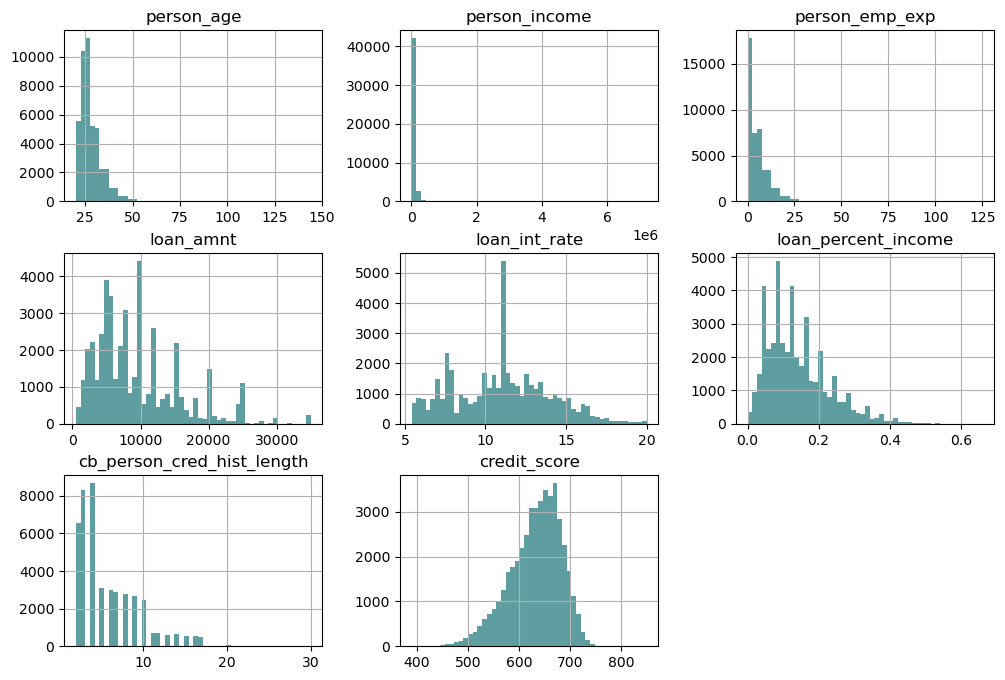

In [7]:
import matplotlib.pyplot as plt
num_df = df[numvars]

num_df.hist(bins = 50, figsize = (12,8), color = 'cadetblue')
plt.show()

**Key Findings**:

Except for **loan_int_rate** and **credit_score**, all other numerical variables exhibited right-skewed distributions. Such skewness could potentially affect model stability, as logistic regression assumes a linear relationship between each predictor and the log-odds of the target variable.

## Summary Statistics

In [8]:
pd.set_option('display.float_format', '{:.2f}'.format)  
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00
mean,27.76,80319.05,5.41,9583.16,11.01,0.14,5.87,632.61,0.22
std,6.05,80422.50,6.06,6314.89,2.98,0.09,3.88,50.44,0.42
min,20.00,8000.00,0.00,500.00,5.42,0.00,2.00,390.00,0.00
25%,24.00,47204.00,1.00,5000.00,8.59,0.07,3.00,601.00,0.00
50%,26.00,67048.00,4.00,8000.00,11.01,0.12,4.00,640.00,0.00
75%,30.00,95789.25,8.00,12237.25,12.99,0.19,8.00,670.00,0.00
max,144.00,7200766.00,125.00,35000.00,20.00,0.66,30.00,850.00,1.00


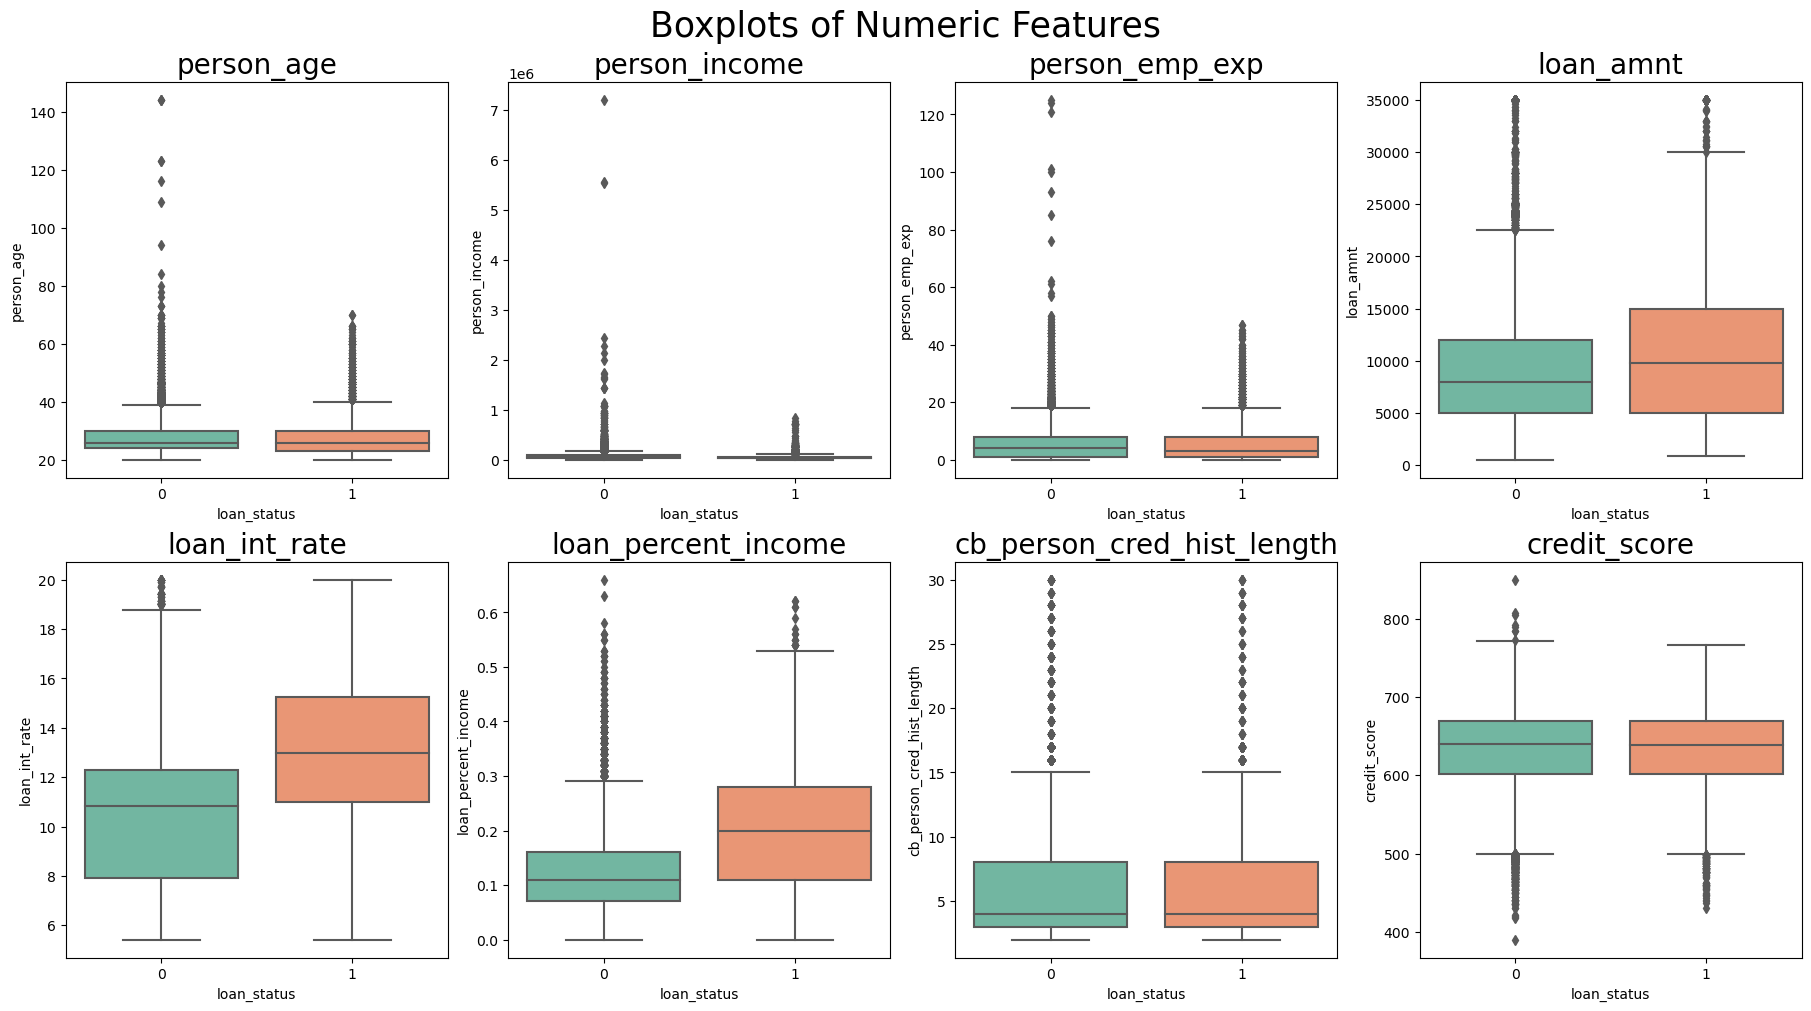

In [9]:
# Plot the boxplots of numeric features
import matplotlib.pyplot as plt
import seaborn as sns
 
fig, axes = plt.subplots(2, 4, 
                         figsize=(18, 10),
                         constrained_layout=True)
axes = axes.flatten() 

for i, var in enumerate(numvars):
    sns.boxplot(x = 'loan_status', 
                y = var, 
                data = df,
                palette = 'Set2',
                ax=axes[i])

    axes[i].set_title(var, fontsize = 20)

plt.suptitle("Boxplots of Numeric Features", fontsize = 25)
plt.show()

**Key Findings**:
1. **person_age**, **person_income**, and **person_emp_exp** exhibited extreme values (e.g., age > 100 years, employment history > 80 years). These cases would be examined to determine whether they should be retained for modeling.
2. For **loan_amnt**, defaulted borrowers (loan_status = 1) tended to have higher loan amounts compared to non-defaulted borrowers (loan_status = 0), suggesting a possible positive relationship between loan amount and credit risk.

## Visualise Categorial Features

In [10]:
for categorical_variable in catvars:
  print("{} -> {}".format(categorical_variable, df[categorical_variable].unique()))

person_gender -> ['male' 'female']
person_education -> ['Associate' 'Master' 'Bachelor' 'High School' 'Doctorate']
person_home_ownership -> ['MORTGAGE' 'RENT' 'OWN' 'OTHER']
loan_intent -> ['EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT' 'PERSONAL'
 'DEBTCONSOLIDATION']
previous_loan_defaults_on_file -> ['No' 'Yes']


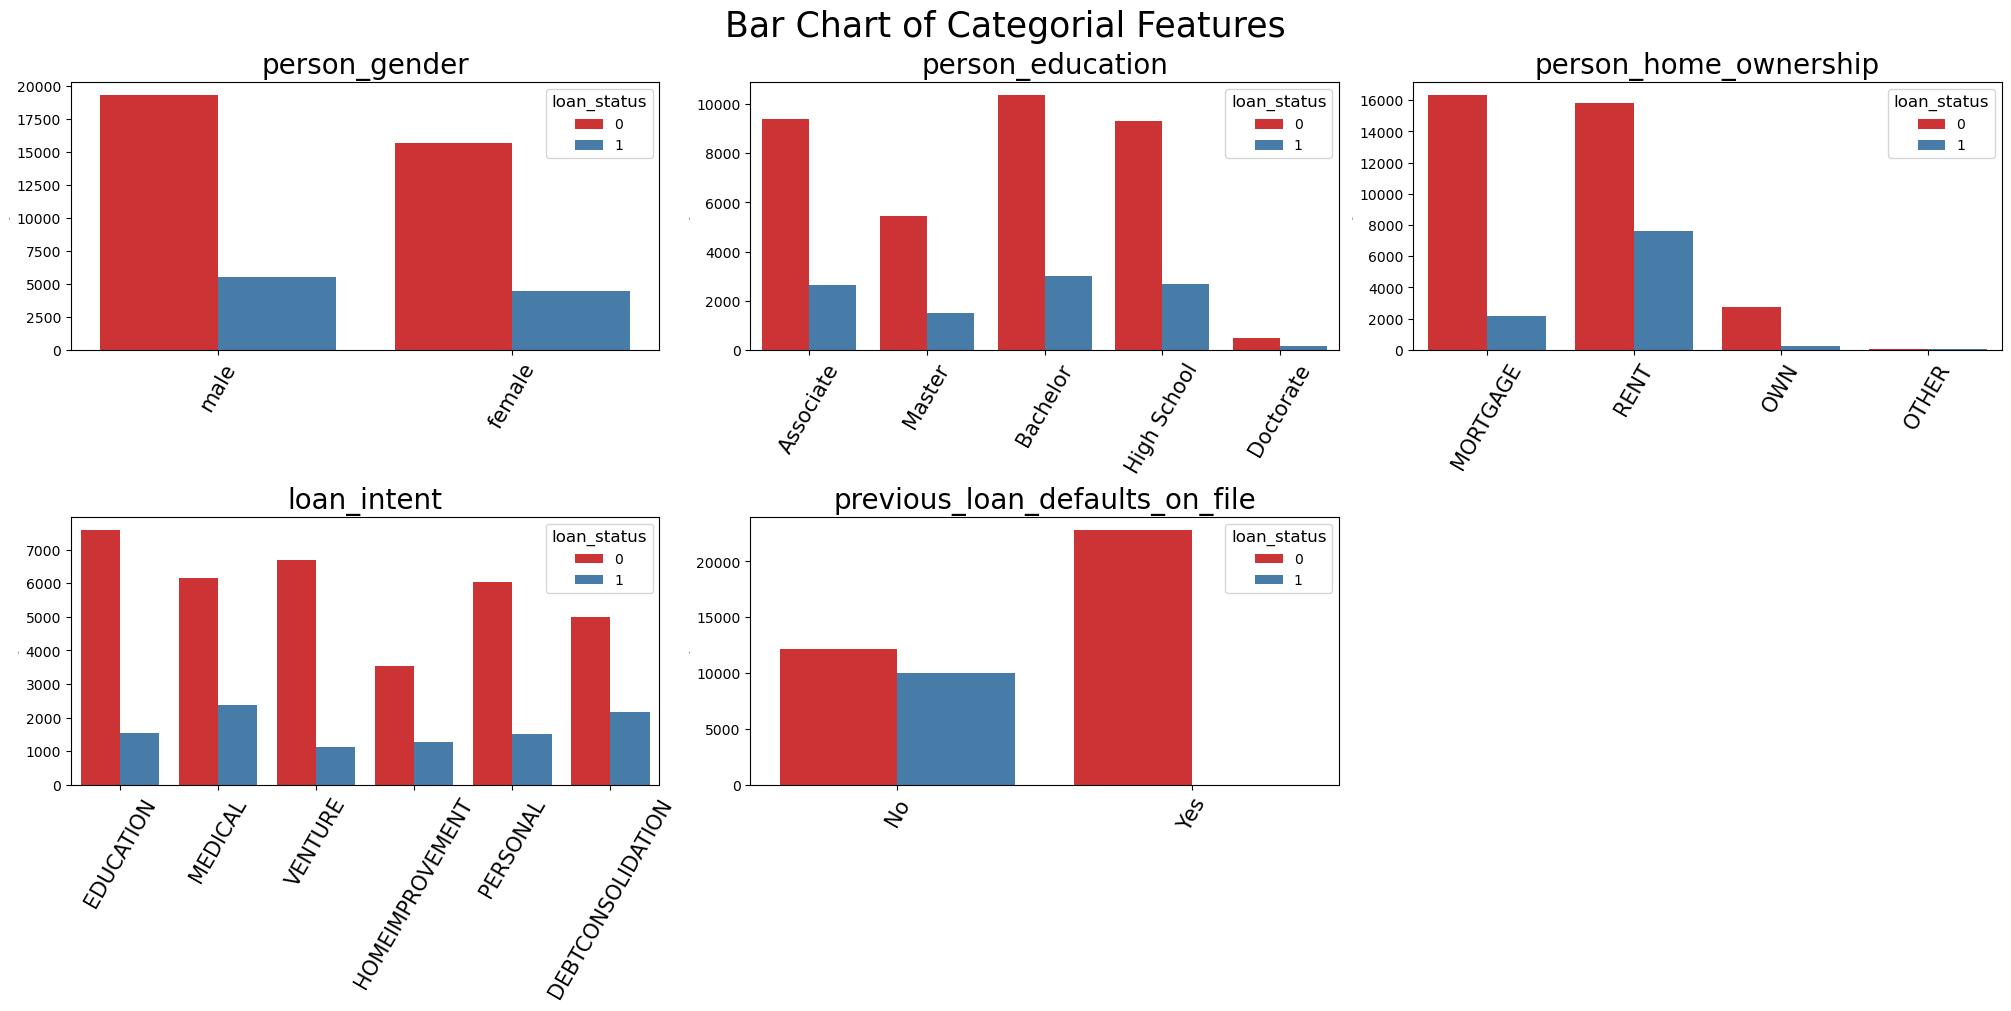

In [11]:
# Plot the bar chart of categorial features
fig, axes = plt.subplots(2, 3, 
                         figsize = (20, 10), 
                         constrained_layout = True)
axes = axes.flatten() 

for i, feature in enumerate(catvars):
    
    sns.countplot(x = feature, 
                  data = df, 
                  hue = 'loan_status', 
                  palette= 'Set1',
                  ax = axes[i])      
    axes[i].set_xlabel('', fontsize = 15)
    axes[i].set_ylabel('Count', fontsize = 1)
    axes[i].tick_params(axis='x', rotation = 60, labelsize = 15)
    axes[i].set_title(feature, fontsize = 20)
    
    handles,labels = axes[i].get_legend_handles_labels()
    axes[i].legend(handles, ['0', '1'], 
                   title = 'loan_status', 
                   loc = 'upper right', 
                   fontsize = 10, 
                   title_fontsize = 12)
    

# Delete the empty plot
for j in range(5, 2 * 3):
    fig.delaxes(axes[j])

plt.suptitle("Bar Chart of Categorial Features", fontsize = 25)
plt.show()

**Key Findings**:
1. **person_gender** and **person_education** showed no meaningful differences between defaulted and non-defaulted borrowers, suggesting limited predictive value.
2. **person_home_ownership** indicated that borrowers who rented their homes were more likely to default compared with homeowners.
3. **loan_intent** suggested that loans taken for medical or debt consolidation purposes were associated with a higher probability of default, potentially reflecting greater financial distress among these borrowers.
4. Notably, almost all borrowers with a prior default record had successfully repaid their loans, which seemed counterintuitive. The following cross-tabulation presented the repayment ratios for borrowers with and without previous defaults.

In [12]:
pd.crosstab(df['previous_loan_defaults_on_file'], df['loan_status'], normalize='index')

loan_status,0,1
previous_loan_defaults_on_file,,
No,0.55,0.45
Yes,1.00,0.00


**Conclusion**:  

Borrowers with a prior default history were observed to have fully repaid their loans in the dataset. This pattern appeared
highly questionable and suggeted the possibility of **data leakage**.

If such a feature was included in the model, borrowers with prior default records might be systematically classified as non-defaulters, leading to severe misclassification risk and potential financial losses for the bank.

Therefore, this predictor would be excluded from the modelling process to prevent biased predictions. 

In [13]:
df = df.drop(columns = ['previous_loan_defaults_on_file'])

In [14]:
catvars.remove('previous_loan_defaults_on_file')

## Target Variable

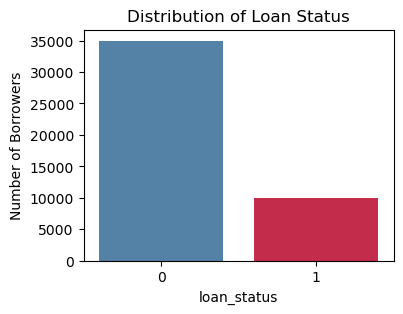

Number of default and non-default borrower:

0    35000
1    10000
Name: loan_status, dtype: int64


In [15]:
# Visualise the distribution of loan status
plt.figure(figsize = (4,3))
sns.countplot(x = 'loan_status', data = df, palette = ['steelblue', 'crimson'])

plt.title("Distribution of Loan Status", fontsize = 12)
plt.xlabel('loan_status', fontsize = 10)
plt.ylabel("Number of Borrowers", fontsize = 10)
plt.show()

print("=" * 50)
print("Number of default and non-default borrower:\n")
print(df['loan_status'].value_counts(dropna=False))

**Conclusion**:  

The dataset showed a reasonably balanced distribution between defaulted and non-defaulted borrowers. Therefore, data resampling methods (e.g., oversampling or SMOTE) were not necessary at this stage.

## Correlation Matrix

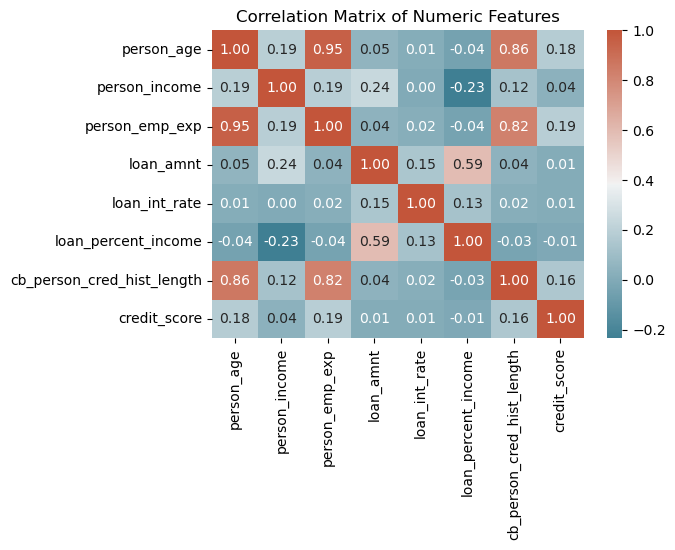

In [16]:
# Construct the correlation matrix
corr = df[numvars].corr(method = 'pearson')
cmap = sns.diverging_palette(220, 20, as_cmap=True)

plt.figure(figsize = (6, 4))
sns.heatmap(corr, annot=  True, 
            cmap = cmap, 
            fmt = '.2f',
            cbar = True,
           annot_kws={'size': 10})
plt.title("Correlation Matrix of Numeric Features", fontsize = 12)
plt.show()

**Key Findings**:  
1. **person_age** exhibited a strong positive correlation with **person_emp_exp** (r = 0.95).
2. **cb_person_cred_hist_length** was also highly correlated with both **person_age** (r = 0.86) and **person_emp_exp** (r = 0.82), suggesting substantial overlap in the information captured by these variables.
3. **loan_amnt** and **loan_percent_income** showed a moderate correlation (r = 0.59), as loan_percent_income was derived from loan_amnt.

The strong correlations among person_age, person_emp_exp, and cb_person_cred_hist_length indicated potential multicollinearity, which could result in unstable coefficient estimates in the logistic regression model. Therefore, these features would be addressed in the subsequent section.

# Data Preprocessing

In the Summary Statistics section, several unrealistic outliers were identified in the **person_age** and **person_emp_exp** variables. These observations were subsequently extracted for further investigation to determine whether they should be retained or removed from the dataset.

## Age and Employment History

In [17]:
# Fetch the borrower data whose age > 100 or employment experience > 80 years
outlier_age = df[(df['person_age'] > 100)|
                    (df['person_emp_exp'] > 80)]
outlier_age

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
3290,123.00,male,Bachelor,94723.00,100,RENT,20000.00,VENTURE,11.01,0.21,4.00,714,0
12476,144.00,male,Bachelor,300616.00,125,RENT,4800.00,VENTURE,13.57,0.02,3.00,789,0
15972,123.00,female,High School,97140.00,101,RENT,20400.00,EDUCATION,10.25,0.21,3.00,805,0
17221,109.00,male,High School,5556399.00,85,MORTGAGE,6195.00,VENTURE,12.58,0.00,22.00,792,0
27253,144.00,female,Associate,7200766.00,124,MORTGAGE,5000.00,PERSONAL,12.73,0.00,25.00,850,0
31414,144.00,male,Associate,241424.00,121,MORTGAGE,6000.00,EDUCATION,11.86,0.02,2.00,807,0
40453,116.00,male,Bachelor,5545545.00,93,MORTGAGE,3823.00,VENTURE,12.15,0.00,24.00,708,0


**Key Findings**:   
This demographic data exhibited implausible values. Both **person_age** and **person_emp_exp** contained unrealistic magnitudes, and the corresponding **cb_person_cred_hist_length** also manifested the anomaly among theses variables.

Therefore, these observations were removed from the dataset to ensure the reliability of subsequent modelling results.

In [18]:
df = df.drop(outlier_age.index)
print("Number of clean data:", len(df))

Number of clean data: 44993


To verify the dataset's logical validity, i.e., that no borrower’s employment experience exceeded their age, a new variable **person_age_emp** was created by subtracting employment years from borrower's age.

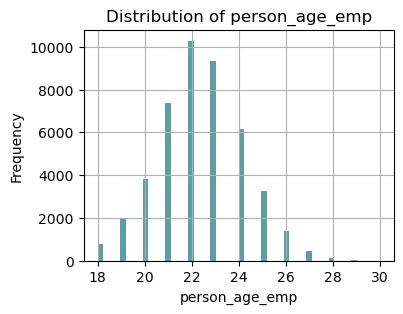

In [19]:
person_age_emp = df['person_age'] - df['person_emp_exp']

person_age_emp.hist(bins = 50, figsize = (4,3), color = 'cadetblue')

plt.title("Distribution of person_age_emp")
plt.xlabel('person_age_emp')
plt.ylabel("Frequency")
plt.show()

**Conclusion**: All data entries appeared reasonable and consistent.

## Work Stability

To better capture the borrower’s employment stability, we created a new feature **work_stability**, which measures the proportion of a borrower’s lifetime spent in working.

This feature was computed as follows, and its values ranged between 0 and 1:

$$\text{Work Stability} = \frac{\text{Employment Experience}}{(\text{Age} - 16)}$$

- A higher value indicated that the borrower had been employed for most of their life, suggesting greater financial stability and a lower probability of default.
- A lower value indicated limited employment experience relative to age, implying lower financial stability and a higher probability of default.

In [20]:
df['work_stability'] = df['person_emp_exp'] / (df['person_age'] - 16)

In [21]:
df['work_stability'].describe()

count   44993.00
mean        0.36
std         0.26
min         0.00
25%         0.12
50%         0.38
75%         0.58
max         0.97
Name: work_stability, dtype: float64

In [22]:
numvars.append('work_stability')

## Credit Level

In practice, banks typically map borrowers' credit scores into discrete risk classes.
- 300 – 579: Poor.
- 580 – 669: Fair.
- 670 – 739: Good.
- 740 – 799: Very Good.
- 800 – 850: Exceptional.

The advantages of binning credit scores include:
1. Mitigating extreme value influence. Grouping very high or very low scores into broader categories reduces the potential impact of outliers on model estimation.
2. Improving alignment with model assumptions. The ordinal structure of the risk classes (from Poor to Exceptional) facilitates a more monotonic relationship with the log-odds in logistic regression.
3. Enhancing interpretability. Binning improves transparency, enabling regulators and non-technical stakeholders to more easily interpret credit risk assessments.

In [23]:
df["credit_score"].describe()

count   44993.00
mean      632.59
std        50.40
min       390.00
25%       601.00
50%       640.00
75%       670.00
max       784.00
Name: credit_score, dtype: float64

After data cleaning, no borrower’s credit score fell within the **Exceptional** category. If the original classification scheme had been maintained, the model would not have been able to estimate the risk associated with this category due to the absence of observations. Therefore, the binning strategy was revised and a new categorisation standard was adopted: 
- 300 – 599: Poor.
- 600 – 669: Fair.
- 670 – 850: Good.

In [24]:
# Bin credit_score
intervals = (299, 599, 669, 850)
categories = ["Poor", "Fair", "Good"]

df["credit_level"] = pd.cut(df.credit_score, intervals, labels = categories)

df['credit_level'] = pd.Categorical(
    df['credit_level'], 
    categories = categories, 
    ordered = True
)

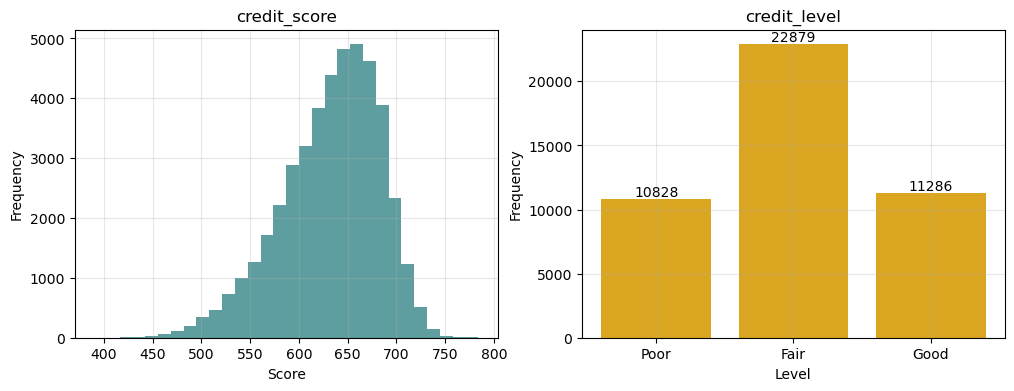

In [25]:
# Set the order
fig, axes = plt.subplots(1, 2, figsize = (12,4))

# Histogram of credit_score
axes[0].hist(df['credit_score'], bins = 30, color = 'cadetblue')
axes[0].set_title("credit_score", fontsize = 12)
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Frequency", fontsize = 10)
axes[0].grid(alpha = 0.3)

# Bar chart of credit_level
counts = df['credit_level'].value_counts().reindex(categories) 
bars = axes[1].bar(counts.index, counts.values, color = 'goldenrod')
axes[1].set_title("credit_level", fontsize = 12)
axes[1].set_xlabel("Level")
axes[1].set_ylabel("Frequency", fontsize = 10)
axes[1].bar_label(bars, fmt = '%d',fontsize = 10)
axes[1].grid(alpha = 0.3)

plt.show()

In [26]:
credit_level_tab = pd.crosstab(df['credit_level'], df['loan_status'], normalize='index')

credit_level_tab.style.format("{:.3f}")

loan_status,0,1
credit_level,,
Poor,0.775,0.225
Fair,0.776,0.224
Good,0.784,0.216


**Key Finding**: As the credit level increased, the default rate showed a slight decline.

In [27]:
catvars.append('credit_level')

## Credibility

The strong correlations among **cb_person_cred_hist_length**, **person_age**, and **person_emp_exp** suggested potential multicollinearity. To address this issue,  a new feature **credibility** was created based on credit history length while incorporating information from the credit score. The original variable was subsequently removed to reduce redundancy. The classification criteria are defined as follows:

- *Very Low*: Credit score < 670 and history length ≤ 4. 
- *Low*: Credit score < 670 and history length > 4. 
- *Medium*: Credit score ≥ 670 and history length ≤ 4. 
- *High*: Credit score ≥ 670 and history length > 4. 

$$
\text{Credibility} =
\begin{cases}
\text{Very Low}, & \text{if } C < 670 \text{ and } t \leq 4 \\
\text{Low}, & \text{if } C < 670 \text{ and } t > 4 \\
\text{Medium}, & \text{if } C \geq 670 \text{ and } t \leq 4 \\
\text{High}, & \text{if } C \geq 670 \text{ and } t > 4
\end{cases}
$$

where:
- $C$ represents the borrower's credit score.
- $t$ is the borrower's credit history length.

Since a credit score of 670 is commonly recognised as the threshold between subprime and prime borrowers, and the median credit history length in our dataset was four years, these values were adopted as classification cut-offs. 

In [28]:
credit_history_threshold = 4

df['credibility'] = np.select(
    condlist = [
        (df['credit_score'] < 670) & (df['cb_person_cred_hist_length'] <= credit_history_threshold),
        (df['credit_score'] < 670) & (df['cb_person_cred_hist_length'] > credit_history_threshold),                                                   
        (df['credit_score'] >= 670) & (df['cb_person_cred_hist_length'] <= credit_history_threshold),
        (df['credit_score'] >= 670) & (df['cb_person_cred_hist_length'] > credit_history_threshold)
    ],
    choicelist = ['Very Low', 'Low', 'Medium', 'High'],
)

In [29]:
credibility_tab = pd.crosstab(df['credibility'], df['loan_status'], normalize='index')

credibility_tab.style.format("{:.3f}")

loan_status,0,1
credibility,,
High,0.791,0.209
Low,0.784,0.216
Medium,0.775,0.225
Very Low,0.769,0.231


**Key Finding**: As the level of credibility increased, the default rate showed a slight decline.

In [30]:
df.drop(columns = ['cb_person_cred_hist_length'], inplace = True)

In [31]:
numvars.remove('cb_person_cred_hist_length')
catvars.append('credibility')

In [32]:
catvars

['person_gender',
 'person_education',
 'person_home_ownership',
 'loan_intent',
 'credit_level',
 'credibility']

# Feature Screening

In this section, univariate logistic regression analyses were performed for numerical variables to assess their statistical significance in explaining the log-odds of default.

For categorical variables, chi-squared tests of independence were conducted as an initial screening step to evaluate whether a significant association existed between each feature and the default outcome.

As both statistical procedures required the default indicator (loan_status), this variable was preserved throughout the data partitioning process. 

In [33]:
# Segment the dataset (80% training set, 20% testing test)
from sklearn.model_selection import train_test_split

X = df
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y # make sure default rate consistent
)

print("The dimension of training set:", X_train.shape)
print("The dimension of testing set:", X_test.shape)

The dimension of training set: (35994, 15)
The dimension of testing set: (8999, 15)


In [34]:
X_train.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,credit_score,loan_status,work_stability,credit_level,credibility
36251,32.00,male,Associate,85907.00,9,MORTGAGE,1500.00,VENTURE,10.27,0.02,576,0,0.56,Poor,Low
9437,44.00,male,Associate,58915.00,21,RENT,7500.00,MEDICAL,11.49,0.13,717,0,0.75,Good,High
26726,27.00,male,Associate,35747.00,4,RENT,3000.00,HOMEIMPROVEMENT,7.01,0.08,652,1,0.36,Fair,Low
13604,24.00,male,Bachelor,44046.00,2,RENT,5000.00,DEBTCONSOLIDATION,14.59,0.11,661,1,0.25,Fair,Very Low
1060,28.00,female,Doctorate,94580.00,5,RENT,24625.00,HOMEIMPROVEMENT,18.36,0.26,675,1,0.42,Good,High


## Univariate Logistic Regression

To conduct preliminary feature selection for numeric variables, univariate logistic regression were estimated, with each predictor individually regressed on the target variable (loan_status). The model is expressed as follows:

$$\log\left(\frac{P(y_i = 1 \mid x_i)}{1 - P(y_i = 1 \mid x_i)}\right) = \beta_0 + \beta_1X_i$$  

where $P$ denotes the probability of default, and $X_i$ represents the $i^{th}$ feature.

The null hypothesis states that the regression coefficient equals zero, implying no association with the log-odds of default. A feature with a p-value greater than 0.05 fails to provides sufficient evidence to reject the null hypothesis at the 5% significance level, suggesting limited statistical evidence of predictive contribution when considered individually.

$$H_0: \beta = 0$$
$$H_1: \beta\neq0$$

In [35]:
import statsmodels.api as sm

uni_results = []

for var in numvars:
    X = sm.add_constant(X_train[[var]]) # Intercept
    y = y_train

    model = sm.Logit(y, X).fit(disp = False) 
    p_value = model.pvalues[var]
    
    uni_results.append({
        'Feature': var,
        'p-value': round(p_value, 4),
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })
    
uni_df = pd.DataFrame(uni_results)
uni_df = uni_df.sort_values(by = 'p-value', ascending = True).reset_index(drop = True)
uni_df

,Feature,p-value,Significant
0,person_income,0.00,Yes
1,loan_amnt,0.00,Yes
2,loan_int_rate,0.00,Yes
3,loan_percent_income,0.00,Yes
4,work_stability,0.00,Yes
5,person_age,0.00,Yes
6,person_emp_exp,0.00,Yes
7,credit_score,0.11,No


**Conclusion**:  

The univariate analysis indicated that **credit_score** was not statistically significant when evaluated as a standalone predictor of default. 

However, this variable may still provide explanatory value in a multivariate setting, particuarly through interaction effects or in combination with correlated features. 

Therefore, credit_score was retained at this stage but flagged as a potential candidate for exclusion in subsequent model refinement.

## Chi-squared Test

For categorical features, the chi-squared test was employed to assess the statistical association between each predictor and the target variable (loan_status). The test constructs a contingency table and calculates the chi-squared statistic by comparing the observed frequencies with the expected frequencies under the assumption of independence. 

$$E_{ij} = \frac{(\text{Row total of category } i)(\text{Column total of category } j)}{\text{Grand total}}$$

E.g., for the default category:
$$E_{i,\text{default}} = (\text{Total frequency of category } i) \times (\text{Default ratio})$$

The chi-squared statistic is then calculated as follows:
$$\chi^2 = \sum_{i=1}^{r} \sum_{j=1}^{c} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

where:
- $O_{ij}$ denotes the observed value in the $i^{th}$ row (categories) and $j^{th}$ column (default or repaid) in the contingency table.
- $E_{ij}$ represents the expected value of default, .
- $r$ is the number of rows.
- $c$ is the number of columns.

The degree of freedom for the chi-squared test are calculated as:
$$df = (i-1)(j-1)$$

The null hypothesis states that the feature and loan_status are independent. A p-value smaller than 0.05 provides sufficient statistical evidence to reject the null hypothesis at the 5% significance level, indicating a significant association between the feature and the default outcome when evaluated individually.
$$H_0: \text{The feature and loan status are independent}$$
$$H_1: \text{The feature and loan status are dependent}$$

In [36]:
from scipy.stats import chi2_contingency

chi2_results = []

for var in catvars:
    cross_tab = pd.crosstab(X_train[var], y_train)
    chi2, p, dof, ex = chi2_contingency(cross_tab)
    chi2_results.append({
        "Feature": var,
        "Chi2": round(chi2, 2),
        "p-value": round(p, 4),
        "Significant": "Yes" if p < 0.05 else "No"
    })

chi2_df = pd.DataFrame(chi2_results).sort_values("p-value")
chi2_df

,Feature,Chi2,p-value,Significant
2,person_home_ownership,2385.29,0.00,Yes
3,loan_intent,696.14,0.00,Yes
5,credibility,11.08,0.01,Yes
4,credit_level,2.35,0.31,No
1,person_education,3.25,0.52,No
0,person_gender,0.41,0.52,No


**Conclusion**:  

The chi-squared test indicated that **credit_level**, **person_gender**, and **person_education** did not exhibit statistically significant associations when evaluated individually. 

However, consistent with the findings from the univariate logistic regression analysis, these variables may still provide explanatory value within a multivariate framework. 

Accordingly, they were retained at this stage but flagged as potential candidates for exclusion in model refinement.

# Feature Transformation

Given logistic regression assumes linearity in the log-odds, predictors exhibiting non-linear patterns were transformed using the Weight of Evidence (WOE) methodology.

## Weight of Evidence (WOE)

The WOE approach discretises continuous or categorial variables into ordered risk segments (bins), typically via decision tree optimisation or chi-squared merging, while preserving monotonicity with respect to default risk. Each bin is assigned a WOE value which represents the logarithmic ratio of the proportion of non-default to default borrowers within that segment. 

$$WOE_i = \ln \left( \frac{\text{Default}_i \ / \ \text{Total Default}}{\text{Repaid}_i \ / \ \text{Total Repaid}} \right)$$
where $i$ is the bin.

In credit risk area, the WOE definition is often formulated as the logarithm of the ratio of the proportion of default to non-default borrowers, which differs from data science conventions.

This specification ensures that **larger** WOE values are directly associated with **higher credit risk**, thereby enhancing interpretability from a risk management perspective.

## Information Value (IV)

To evaluate the overall discriminatory power of a feature, the Information Value (IV) metric was introduced, which was calculated based on the corresponding WOE values. 

IV measures the degree of separation between defaulters and non-defaulters across bins, serving as a indicator of a variable's predictive contribution in the model. The IV formulation is given by:

$$\text{IV}_i = \sum_i (\text{Default%}_i - \text{Repaid%}_i) \times WOE_i$$

In general, an IV value below 0.02 suggests that the variable has negligible discriminatory power and may contribute minimally to the model’s predictive capability.

## Pool Adjacent Violators Algorithm (PAVA)

The Pool Adjacent Violators Algorithm (PAVA) enforces monotonicity by merging adjacent bins that violate a specified trend (either increasing or decreasing). However, the algorithm itself does not automatically determine the overall monotonic direction of the WOE values.

To address this, the **detect_direction** function is introduced to identify the underlying trend of the WOE values by calculating the correlation between the bin order and the corresponding WOE values. This step ensures that PAVA preserves the inherent relationship between the predictor and default risk, rather than distorting the risk structure through an incorrectly imposed monotonic constraint. 

In [37]:
def detect_direction(woe_df, direction = 'auto'):
    """
    Determine whether the WOE trend is increasing or decreasing.
    
    Parameters:
        woe_df (pd.DataFrame): DataFrame containing the 'woe' column.
        direction (str): Trend detection mode.
            - 'auto': Automatically determine trend using correlation coefficient. 
            - 'increasing': Force return True.
            - 'decreasing': Force reture False.
    
    Returns:
        bool: True if the trend is increasing, False if decreasing.
    """
    if direction == 'auto':
        corr = np.corrcoef(np.arange(len(woe_df)), woe_df['woe'])[0, 1]
        return corr >= 0
    else:
        return direction == 'increasing'

After identifying the overall trend, the **check_monotonicity** function is applied to verify whether the WOE values comply with the designated monotonic direction. It prevents unnecessary bin merging when the WOE values are already monotonic. By confirming monotonicity prior to adjustment, this step prevents redundant bin merging and avoids unnecessary computational operations.

In [38]:
def check_monotonicity(woe_values, increasing):
    """
    Check whether WOE values follow the specified monotonic direction.
    
    Parameters:
        woe_values (array-like): WOE values to be checked (e.g., list, np.array, or pd.Series).
        increasing (bool): The expected monotonic direction.
            - True: Validate if the values are monotonically increasing.
            - False: Validate if the values are monotonically decreasing.
    
    Returns:
        bool: True if the sequence satisfies the specified direction, False otherwise. 
    """
    if increasing:
        return np.all(np.diff(woe_values) >= 0)
    else:
        return np.all(np.diff(woe_values) <= 0)

If violations are detected, the **apply_pava** function is invoked to iteratively enforce the monotonic constraint. During each iteration, the **merge_bins** function combines the violating bin with its preceding bin. The counts of observations, non-defaults, and defaults are aggregated to form a new consolidated bin. After merging, both the default probability and the WOE values are recalculated to reflect the updated distribution. The redundant bin is subsequently removed, and the index is reset to maintain structural consistency.

In [39]:
def merge_bins(df, idx):
    """
    Merge adjacent bins when a monotonicity violation is detected and remove the redundant row.
    
    Parameters:
        df (pd.DataFrame): The WOE summary DataFrame containing coulumns:
            - 'count_distr': Total number of observations in each bin. 
            - 'good': Number of non-defaulters.
            - 'bad': Number of defaulters.
            - 'badprob': Proportion of defaulters within the bin. 
            - 'woe': Weight of evidence value for the bin.
        idx (int): The index of the bin to be merged into its preceding bin (idx - 1).

    Returns:
        pd.DataFrame: An updated DataFrame with merged bin statistics and a reset index.
    """
    df.loc[idx - 1, 'count_distr'] += df.loc[idx, 'count_distr']
    df.loc[idx - 1, 'good'] += df.loc[idx, 'good']
    df.loc[idx - 1, 'bad'] += df.loc[idx, 'bad']
    
    total_good = df['good'].sum()
    total_bad = df['bad'].sum()
    
    goodrate = df.loc[idx - 1, 'good'] / total_good
    badrate = df.loc[idx - 1, 'bad'] / total_bad
    
    df.loc[idx - 1, 'badprob'] = (
        df.loc[idx - 1, 'bad'] / (df.loc[idx - 1, 'good'] + df.loc[idx - 1, 'bad'])
    )
    
    df.loc[idx - 1, 'woe'] = np.log((goodrate + 1e-6) / (badrate + 1e-6))
    
    return df.drop(idx).reset_index(drop = True)

def apply_pava(df, increasing = True):
    """
    Apply the Pool Adjacent Violators Algorithm (PAVA) to ensure monotonic WOE trends.
    
    Parameters:
        df (pd.DataFrame): The WOE summary table.
        increasing (bool): The specified monotonic direction. Defaults to True.
        
    Returns:
        pd.DataFrame: A modified DataFrame where WOE values are strictly monotonic. 
    """
    df = df.copy().reset_index(drop = True)
    
    while True:
        violation = False
        
        for idx in range(1, len(df)):
            if (increasing and df.loc[idx, 'woe'] < df.loc[idx - 1, 'woe']) or \
                (not increasing and df.loc[idx, 'woe'] > df.loc[idx - 1, 'woe']):
                
                df = merge_bins(df, idx)
                violation = True
                break
                
        if not violation:
            break
        
    return df

Finally, the **enforced_monotonicity** function serves as the overall control procedure that automates this process across multiple variables.

For each variable, the function first determines the overall WOE trend using **detect_direction**, and then verifies whether the WOE values already satisfy the specified monotonic constraint through **check_monotonicity**.

If violations are detected, the **apply_pava** function is invoked to adjust the binning structure, while variables that already satisfy the monotonic condition remain unchanged.

The iterative merging process continues until no further violations remain, at which point all the WOE values satisfies the monotonic requirement for logistic regression modelling. 

In [40]:
def enforce_monotonicity(bins_dict, direction = 'auto', log = True):
    """
    Automate the monotonicity check and PAVA adjustment across variables.
    
    Parameters:
        bins_dict (dict): A dictionary containing binning results and WOE values of variables.
        direction (str): Trend detection mode ('auto', 'increasing', or 'decreasing').
        log (bool): If True, prints detailed logs of the adjustment process.
        
    Returns:
        dict: A dictionary containing the updated DataFrames, where all features satisfy monotonic constraints.
    """
    bins_out = {} # Final results
    adjusted_vars = []
    
    for var, df in bins_dict.items():
        woe_df = df.copy().reset_index(drop = True)
        
        if len(woe_df) <= 1:
            bins_out[var] = woe_df
            continue
            
        original_bins = len(woe_df)
        
        woe_values = woe_df['woe'].values
        
        increasing = detect_direction(woe_df, direction)
        
        # Skip PAVA if the WOE values are monotonic
        if check_monotonicity(woe_values, increasing):
            bins_out[var] = woe_df
            continue
        
        if log:
            print(f"PAVA applied to: {var}")
            
        adjusted_vars.append(var)
        
        woe_df = apply_pava(woe_df, increasing)
        
        if log:
            print(f"Bins: {original_bins} -> {len(woe_df)}")
            
        bins_out[var] = woe_df
        
    if log:
        if not adjusted_vars:
            print("No variables required PAVA adjustment.")
        else:
            print("Adjusted variables:", adjusted_vars)
            
    return bins_out

## Features Binning and Visualisation

In the following section, WOE binning results were visualised to examine the distribution of default rates across different risk segments. These visualisations facilitated validation of whether each feature exhibited a monotonic relationship with the log-odds of default, thereby supporting the linearity assumption of logistic regression.

The following stacked bar charts display bin proportions and class distributions, while the line charts depict default rate (bad rate) trends.

In [41]:
# Decision tree binning
import scorecardpy as sc

num_bins = sc.woebin(X_train, 
                    y = 'loan_status', 
                    x = numvars, 
                    method = 'tree',
                    positive = 1,
                    min_perc_fine_bin = 0.08,
                    stop_limit = 0.1,
                    bin_num_limit = 5,
                    special_values = None)

[INFO] creating woe binning ...


In [42]:
num_bins_adjusted = enforce_monotonicity(num_bins)

No variables required PAVA adjustment.


In [43]:
def bin_plot(bins, varlist, ncols=3, figsize=(15, 10)):

    n = len(varlist)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize = figsize)
    axes = axes.flatten()

    for i, varname in enumerate(varlist):
        ax1 = axes[i]
        df = bins[varname].copy()

        bins_label = df['bin']
        good = df['good']
        bad = df['bad']
        total = df['count']
        bad_rate = df['badprob']
        count_distr = df['count_distr']

        good_prop = good / total
        bad_prop = bad / total

        # Left axis (bar chart)
        ax1.bar(bins_label, good_prop * count_distr, label = 'Repaid', color = 'powderblue')
        ax1.bar(bins_label, bad_prop * count_distr, bottom = good_prop * count_distr, label = 'Default', color = 'lightseagreen')
        ax1.tick_params(axis = 'x', rotation = 25, labelsize = 8)
        ax1.set_ylabel('Count dist.', fontsize = 9)
        ax1.set_xlabel(varname, fontsize = 9)

        # Right axis (line chart)
        ax2 = ax1.twinx()
        ax2.plot(bins_label, bad_rate, color = 'tomato', marker = 'o', linewidth = 2)
        ax2.tick_params(axis = 'y', labelcolor = 'red', labelsize = 8)

        ax1.set_title(f"{varname}", fontsize = 10, pad = 8)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc = 'upper center', ncol = 2, fontsize = 10, frameon = False)
    plt.tight_layout(rect = [0, 0, 1, 0.97])
    plt.show()

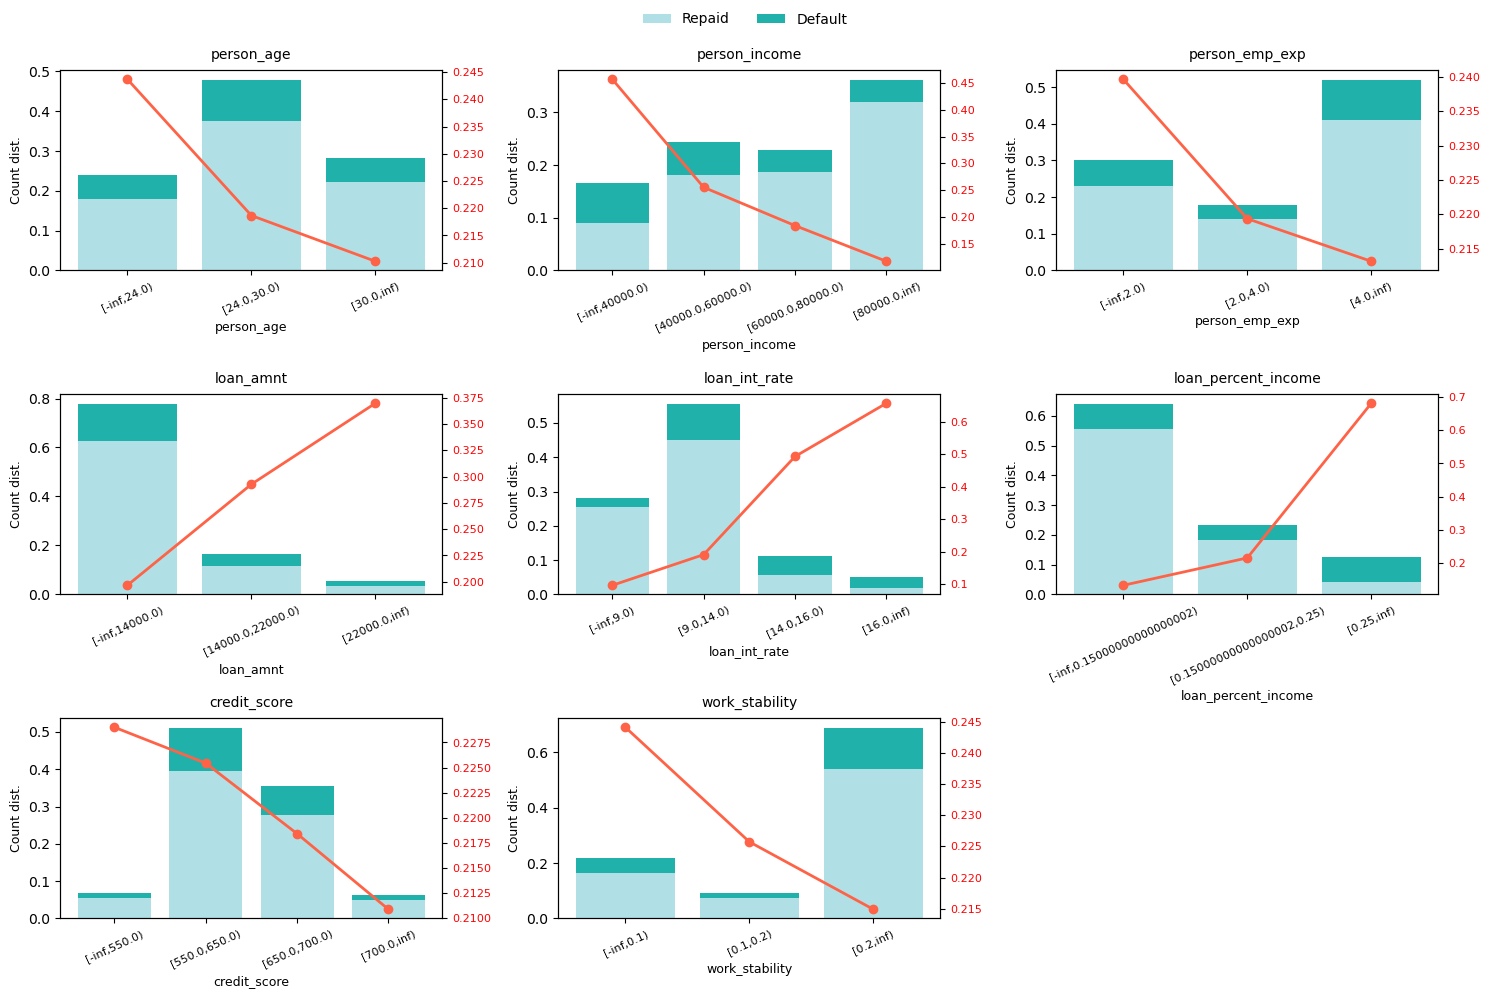

In [44]:
bin_plot(num_bins_adjusted, numvars) 

**Key Findings:**

1. The bad rate (default rate) curves exhibited monotonic behaviour across bins for all numerical cariables, supporting the stability of the binning structure.
2. Features such as **loan_amnt**, **loan_int_rate**, and **loan_percent_income** showed a clear positive relationship with default risk, where higher values are associated with increased probability of default.

Unlike numerical variables, categorial features do not inherently possess a natural ordinal structure. Therefore, monotonic constraints were generally not imposed during binning. Instead, their predictive contribution was directly evaluated based on the information value. ensuring that categorial risk segmentation remained data-drivenrather than artificially constrained by directional assumptions.

Although **credibility** and **credit_level** exhibited an inherent ordinal structure, prior analysis (Data Preprocessing) confirmed that the default rate decreased consistently as the category level increased. Since the empirical risk pattern already satisfied the expected monotonic relationship, no additional monotonic enforcement was applied.

In [45]:
cat_bins = sc.woebin(X_train, 
                    y = 'loan_status', 
                    x = catvars, 
                    method = 'tree',
                    positive = 1,
                    min_perc_fine_bin = 0.08,
                    stop_limit = 0.1,
                    bin_num_limit = 5,
                    special_values = None)

[INFO] creating woe binning ...


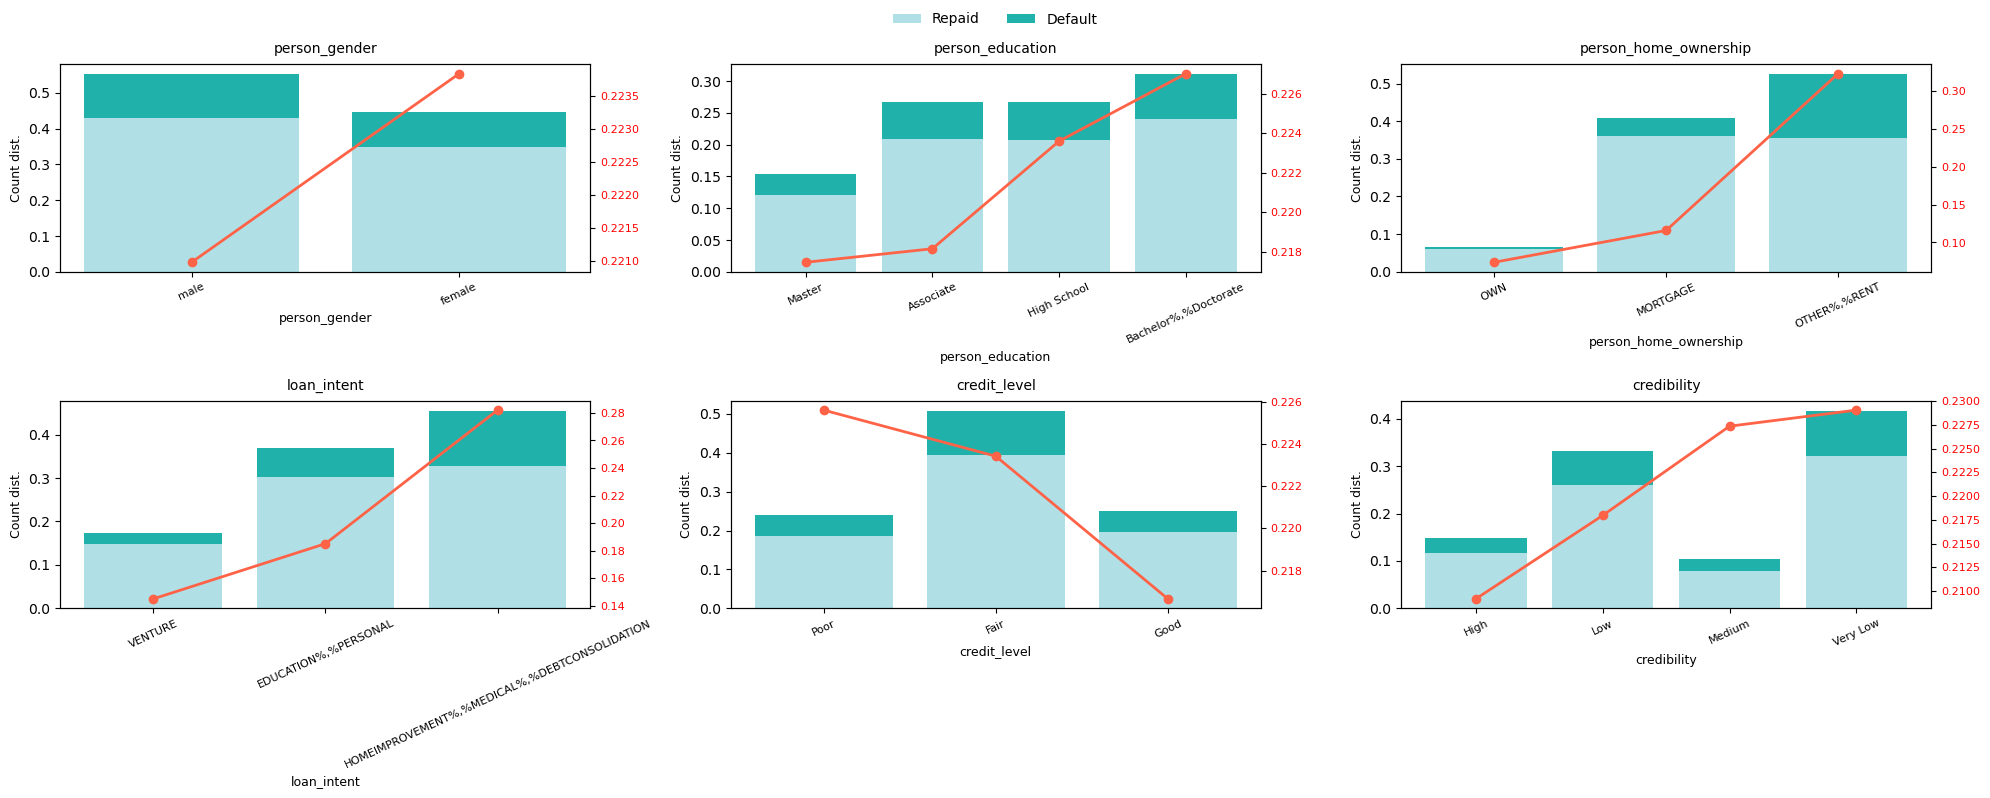

In [46]:
bin_plot(cat_bins, catvars, figsize = (20, 8)) 

**Key Findings:**

Overall, risk differentiation among categorical variables was primarily driven by **person_home_ownership** and **loan_intent**, while other demographic characteristics contribute minimally to predictive performance.

## WOE Trend Visualisation

Although default rate curves illustrate the raw risk distribution, the logistic regression model operates on WOE-transformed variables. To ensure consistency between risk patterns and model inputs, the WOE values were plotted and examined for monotonic trends.

The **woe_plot** function visualised the WOE values across bins for each variable, while also displaying the corresponding information value to indicate variable strength.

In [47]:
def woe_plot(bins, varlist, ncols=3, figsize=(15, 10)):

    n = len(varlist)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten()

    for i, varname in enumerate(varlist):
        ax = axes[i]
        df = bins[varname]
        ax.plot(df['bin'], df['woe'], marker = 'o', color = 'goldenrod', linewidth = 2)
        ax.axhline(0, color = 'gray', linestyle = '--', linewidth = 1)
        ax.set_title(f"{varname}\n(IV={df['total_iv'].iloc[0]:.4f})", fontsize = 10)
        ax.set_xlabel("Bins", fontsize = 8)
        ax.set_ylabel("WOE", fontsize = 8)
        ax.tick_params(axis = 'x', rotation = 25, labelsize = 8)
        ax.grid(alpha = 0.3)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        

    plt.tight_layout()
    plt.show()

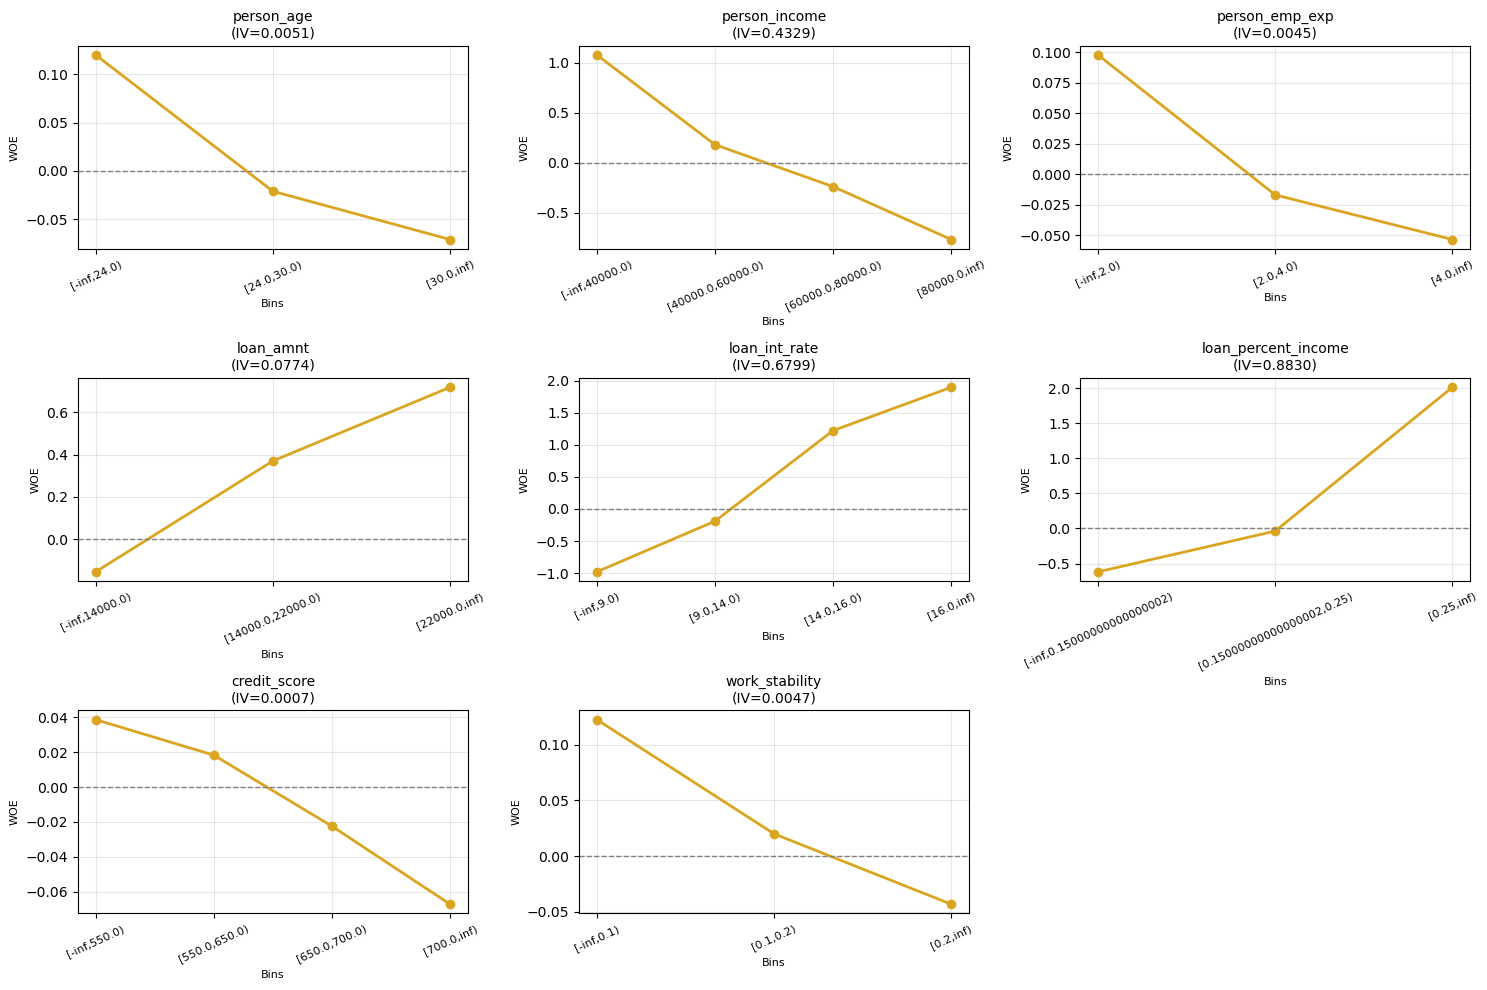

In [48]:
woe_plot(num_bins_adjusted, numvars)

**Key Findings**:

1. The WOE profiles demonstrate clear and stable monotonic pattern across bins for all numerical variables, indicating well-structured risk ordering.
2. Features **person_income**,**loan_amnt**, **loan_int_rate**, and **loan_percent_income** demonstrate meaningful discriminatory power, with information values exceeding 0.02.

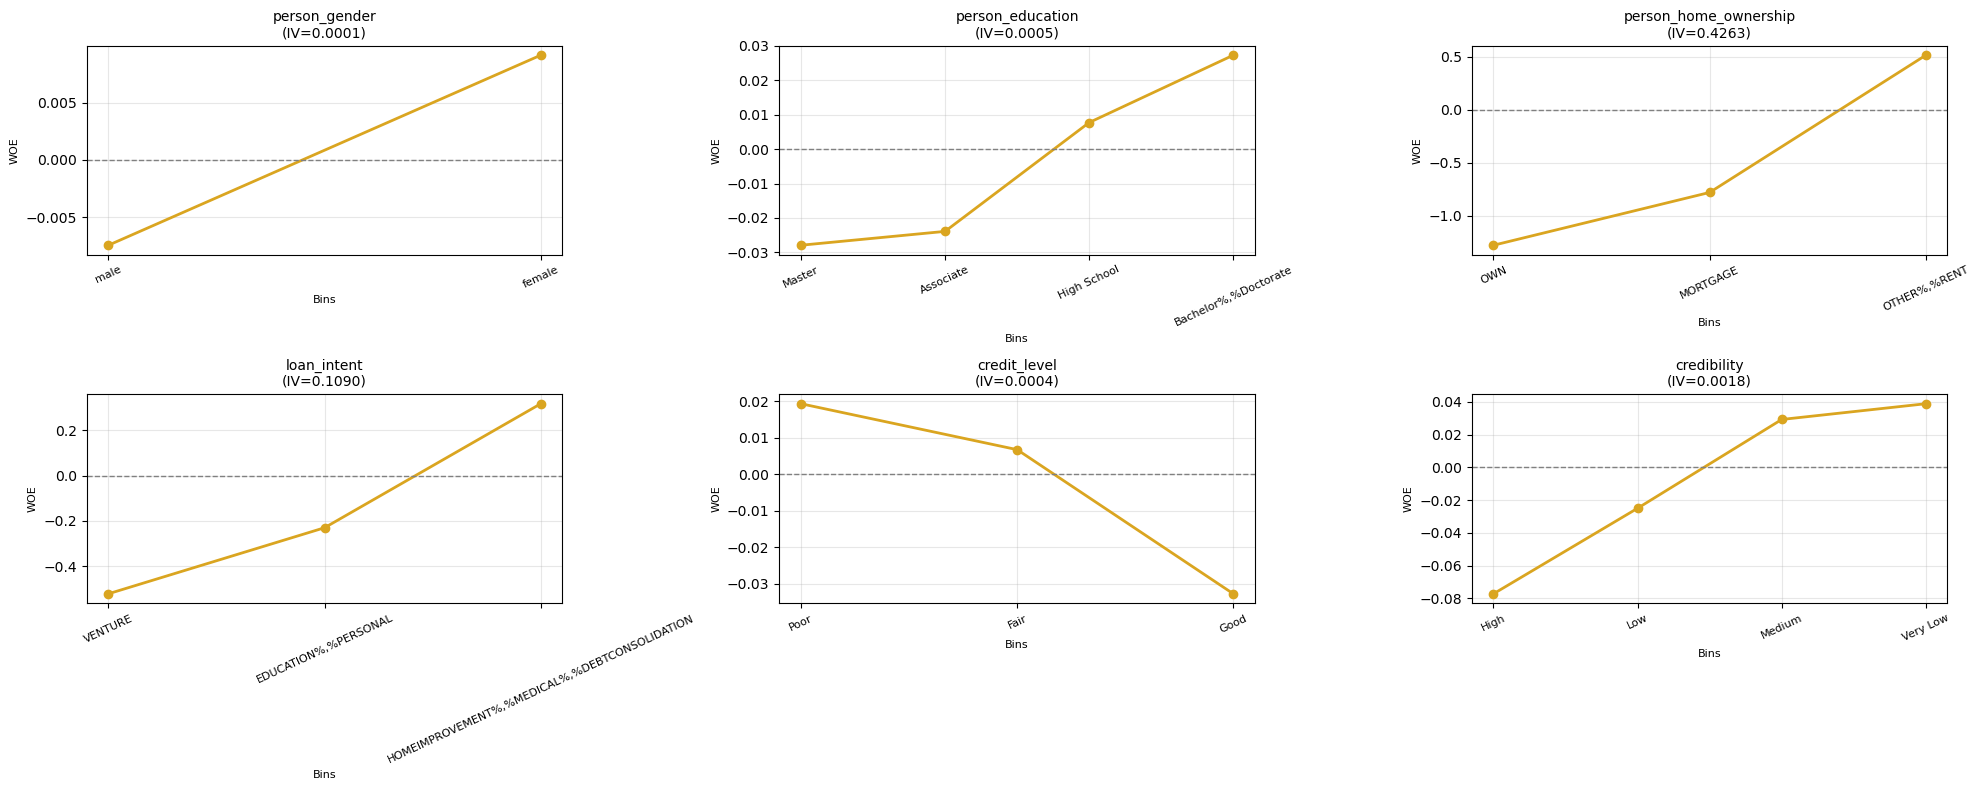

In [49]:
woe_plot(cat_bins, catvars, figsize = (20, 8))

**Key Findings**:  

Most categorical variables exhibited negligible discriminatory power, as indicated by their near-zero information values, whereas **person_home_ownership** and **loan_intent** demonstrated meaningful predictive contribution to default risk.

In [50]:
# Combine numerical and categorial bins
all_bins = num_bins_adjusted.copy()
all_bins.update(cat_bins)

Variables with Information Values below 0.02 were removed from both the training and testing datasets prior to model development to reduce noise.

In [51]:
# Remove variables with IV value < 0.02
X_train.drop(columns = ['loan_status', 'person_age', 'person_emp_exp', 'credit_score',
                        'work_stability', 'person_gender', 'person_education', 'credit_level', 'credibility'], inplace = True)
X_test.drop(columns = ['loan_status', 'person_age', 'person_emp_exp', 'credit_score',
                        'work_stability', 'person_gender', 'person_education', 'credit_level', 'credibility'], inplace = True)

## Correlation Martix

After validating the monotonic risk structure of individual variables, the next step was transformed all values in the dataset into their correspondding WOE representations.

Subsequently, a correlation matrix was constructed based on the WOE-transformed variables to evaluate potential multicollinearity among predictors. Since WOE encoding converted all features into continuous risk-based measures, computing correlation matrix in the WOE space provided a more meaqningful evaluation of redundancy between variables.

In [52]:
X_train_woe = sc.woebin_ply(X_train, all_bins)
X_test_woe = sc.woebin_ply(X_test, all_bins)

[INFO] converting into woe values ...
[INFO] converting into woe values ...


In [53]:
X_train_woe

,person_income_woe,person_home_ownership_woe,loan_amnt_woe,loan_percent_income_woe,loan_intent_woe,loan_int_rate_woe
36251,-0.77,-0.78,-0.15,-0.62,-0.52,-0.19
9437,0.18,0.51,-0.15,-0.62,0.32,-0.19
26726,1.08,0.51,-0.15,-0.62,0.32,-0.98
13604,0.18,0.51,-0.15,-0.62,0.32,1.22
1060,-0.77,0.51,0.72,2.01,0.32,1.90
...,...,...,...,...,...,...
2451,1.08,-0.78,-0.15,2.01,-0.23,-0.19
41108,-0.24,0.51,0.37,2.01,0.32,-0.98
26039,-0.77,-0.78,-0.15,-0.62,0.32,-0.19
38553,0.18,-0.78,-0.15,-0.04,0.32,-0.98


Before conducting LASSO, we need to ensure that there are no highly correlated features in the dataset, as strong multicollinearity can make the model coefficients unstable. Therefore, we re-plot the correlation matrix using the WOE-transformed data.

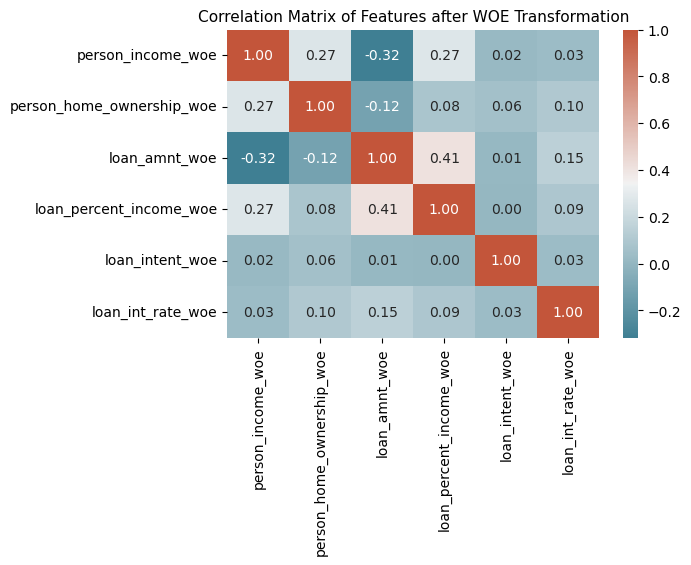

In [54]:
corr_woe =  X_train_woe.corr(method = 'pearson')
cmap = sns.diverging_palette(220, 20, as_cmap = True)

plt.figure(figsize = (6, 4))
sns.heatmap(corr_woe, annot=  True, 
            cmap = cmap, 
            fmt = '.2f',
            cbar = True,
           annot_kws={'size': 10})
plt.title("Correlation Matrix of Features after WOE Transformation", fontsize = 11)
plt.show()

**Key Findings**: 

1. The correlation matrix of WOE-transformed variables indicated no evidence of severe multicollinearity. 
2. The highest observed correlation (0.41) occurred between **loan_percent_income** and **loan_amnt**, reflecting an economically intuitive relationship.

## Variation Inflation Factor (VIF)

While the correlation matrix evaluated pairwise linear relationships between features, the Variance Inflation Factor (VIF) provided a more comprehensive assessment of multicollinearity by examining how strongly each feature was explained by all other predictors.

Specifically, the VIF for a feature is calculated by regressing that feature on the remaining variables and computing:

$${VIF}_i = \frac{1}{1-{R^2}_i}$$

where ${R^2}_i$ represents the coefficient of determination obtained from regressing feature $X_i$ on all other features.  

A VIF value greater than 10 is commonly interpreted as indicating substantial multicollinearity, suggesting that the feature is largely explained by other predictors and may require removal or adjustment.

In [55]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(X_train_woe)

vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

vif_data

,feature,VIF
0,const,1.10
1,person_income_woe,1.49
2,person_home_ownership_woe,1.10
3,loan_amnt_woe,1.62
4,loan_percent_income_woe,1.54
5,loan_intent_woe,1.00
6,loan_int_rate_woe,1.04


**Conclusions**: There is no severe multicollinearity among WOE-transformed features.

# Least Absolute Shrinkage and Selection Operator (LASSO)

Since multicollinearity has been shown to be negligible among the retained features, LASSO can be applied with greater confidence to identify the most influential predictors for credit risk modelling.

LASSO is a widely used regularisation technique in machine learning that introduces a penalty term during model estimation. By adding an L1 penalty to the objective function, LASSO simultaneously controls model complexity and conducts feature selection. This regularisation mechanism helps prevent overfitting while identifying the most informative predictors.
In the context of logistic regression, the predicted probability of default is defined as:

$$P(y_i = 1 | x_i) = \frac{1}{1 + e^{-(\beta_0 + \beta_1x_1 + ...+\beta_nx_n)}}$$

The objective is to estimate a set of coefficients that maximises the log-likelihood function:

$$ \text{maximize}\ L(\beta) = \sum_{i=1}^{n} \big[ y_i \log(p_i) + (1 - y_i)\log(1 - p_i) \big]$$
where $p_i = P(y_i = 1 | x_i)$.

This optimisation can be expressed as a minimisation problem with an added L1 penalty:
$$\text{minimize}\ J(\beta) = -L(\beta) + \lambda \sum_{j=1}^{p} |\beta_j|$$
where:
- $J(\beta)$ is the regularised objective function.
- $\lambda \sum_{j=1}^{p} |\beta_j|$ is the L1 penalty term.

The purpose of the penalty term is to shrink large coefficients and force less important coefficients toward zero, effectively filtering out irrelevant predictors.

In [56]:
X_train_woe.describe()

,person_income_woe,person_home_ownership_woe,loan_amnt_woe,loan_percent_income_woe,loan_intent_woe,loan_int_rate_woe
count,35994.00,35994.00,35994.00,35994.00,35994.00,35994.00
mean,-0.11,-0.13,-0.02,-0.15,-0.03,-0.15
std,0.64,0.69,0.26,0.86,0.33,0.79
min,-0.77,-1.28,-0.15,-0.62,-0.52,-0.98
25%,-0.77,-0.78,-0.15,-0.62,-0.23,-0.98
50%,-0.24,0.51,-0.15,-0.62,-0.23,-0.19
75%,0.18,0.51,-0.15,-0.04,0.32,-0.19
max,1.08,0.51,0.72,2.01,0.32,1.90


**Conclusion**: Standardisation was not required here because the features had already been transformed using WOE encoding.

In [57]:
# LASSO
from sklearn.linear_model import LogisticRegressionCV

lasso = LogisticRegressionCV(
    Cs = np.logspace(-3, 1, 30), # Try 30 Cs (cross validation), from 0.001 to 10, where C=1/λ
    penalty = 'l1',
    solver = 'saga', # Solver for L1
    cv = 5,
    scoring = 'roc_auc', # Maximum iterative times
    max_iter = 5000,
    n_jobs = -1,
    random_state = 42
)

lasso.fit(X_train_woe, y_train)

LogisticRegressionCV(Cs=array([1.00000000e-03, 1.37382380e-03, 1.88739182e-03, 2.59294380e-03,
       3.56224789e-03, 4.89390092e-03, 6.72335754e-03, 9.23670857e-03,
       1.26896100e-02, 1.74332882e-02, 2.39502662e-02, 3.29034456e-02,
       4.52035366e-02, 6.21016942e-02, 8.53167852e-02, 1.17210230e-01,
       1.61026203e-01, 2.21221629e-01, 3.03919538e-01, 4.17531894e-01,
       5.73615251e-01, 7.88046282e-01, 1.08263673e+00, 1.48735211e+00,
       2.04335972e+00, 2.80721620e+00, 3.85662042e+00, 5.29831691e+00,
       7.27895384e+00, 1.00000000e+01]),
                     cv=5, max_iter=5000, n_jobs=-1, penalty='l1',
                     random_state=42, scoring='roc_auc', solver='saga')

In [58]:
# Optimal C
best_C = lasso.C_
print(f"The best C value: {best_C[0]:.4f}")

The best C value: 10.0000


**Conclusion:**

The selection of a relatively large regularization parameter (C = 10) indicated that only limited shrinkage was required. This was consistent with the prior IV screening and VIF assessment, which had already mitigated multicollinearity and removed irrelevant variables before model estimation.

In [59]:
# LASSO feature selection results
lasso_coef = lasso.coef_.flatten()
coef_df = pd.DataFrame({
    'feature': X_train_woe.columns,
    'coefficient': lasso_coef
}).sort_values(by='coefficient', ascending=False)

selected_features = coef_df[coef_df['coefficient'] != 0]
dropped_features = coef_df[coef_df['coefficient'] == 0]

print("\n==========================================")
print("Selected Features (In Descending Order)")
print("==========================================")
print(selected_features)
print("\n==========================================")
print("Features Dropped by LASSO")
print("==========================================")

if dropped_features.empty:
    print("Features Dropped by LASSO: None")
else:
    print(dropped_features)


Selected Features (In Descending Order)
                     feature  coefficient
4            loan_intent_woe         1.31
5          loan_int_rate_woe         1.19
3    loan_percent_income_woe         1.02
1  person_home_ownership_woe         0.92
0          person_income_woe         0.76
2              loan_amnt_woe         0.24

Features Dropped by LASSO
Features Dropped by LASSO: None


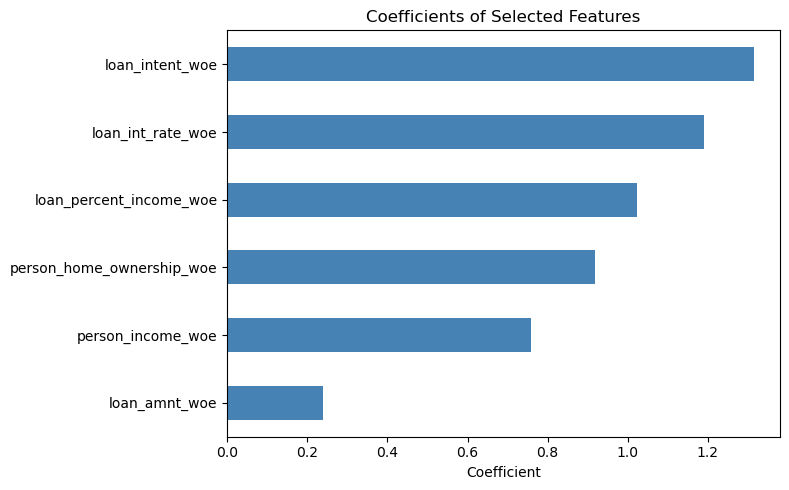

In [60]:
# Visualised the key risk factors' directional effects and magnitudes
selected_features_sorted = selected_features.sort_values(by = 'coefficient')

colours = ['crimson' if x < 0 else 'steelblue'
           for x in selected_features_sorted['coefficient']]

selected_features_sorted.plot(
    kind='barh',
    x = 'feature',
    y = 'coefficient',
    color=colours,
    figsize=(8, 5)
)

plt.xlabel('Coefficient', fontsize=10)
plt.ylabel('', fontsize=10)
plt.title('Coefficients of Selected Features')
plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

**Conclusions:** 

Among the selected predictors, **loan_intent** exhibited the strongest influence on the log-odds of default, while **loan_amnt** demonstrated the weakest marginal contribution within the model.

**Note:**
Since the predictors were transformed using WOE encoding, the direction of risk was inherently embedded in the WOE values. Therefore, the regression coefficients here reflected the relative strength of each predictor rather than the raw directional relationship with default probability.

In [61]:
lassovars = X_train_woe.columns.tolist()

In [62]:
lassovars

['person_income_woe',
 'person_home_ownership_woe',
 'loan_amnt_woe',
 'loan_percent_income_woe',
 'loan_intent_woe',
 'loan_int_rate_woe']

In [63]:
X_train_lasso = X_train_woe[lassovars]
X_test_lasso = X_test_woe[lassovars]

In [64]:
X_train_lasso

,person_income_woe,person_home_ownership_woe,loan_amnt_woe,loan_percent_income_woe,loan_intent_woe,loan_int_rate_woe
36251,-0.77,-0.78,-0.15,-0.62,-0.52,-0.19
9437,0.18,0.51,-0.15,-0.62,0.32,-0.19
26726,1.08,0.51,-0.15,-0.62,0.32,-0.98
13604,0.18,0.51,-0.15,-0.62,0.32,1.22
1060,-0.77,0.51,0.72,2.01,0.32,1.90
...,...,...,...,...,...,...
2451,1.08,-0.78,-0.15,2.01,-0.23,-0.19
41108,-0.24,0.51,0.37,2.01,0.32,-0.98
26039,-0.77,-0.78,-0.15,-0.62,0.32,-0.19
38553,0.18,-0.78,-0.15,-0.04,0.32,-0.98


# Logistic Regression

The final logistic regression model is specified as:

$$
\log \left(
\frac{P(y_i = 1 \mid x_i)}{1 - P(y_i = 1 \mid x_i)}
\right)
= \beta_0 + \sum_{i=1}^{k} \beta_i \text{WOE}_i
$$

where:
- $\beta_i$ denote the estimated regression coefficients.
- $\text{WOE}_i$ represent the WOE-transformed features.  

To convert the log-odds into predicted probabilities within the range between 0 and 1, the sigmoid function is applied:
$$\sigma(z) = \frac{1}{1+e^{-z}}$$

Accordingly, the predicted probability of default is expressed as:
$$
P(y_i = 1 \mid x_i) =
\frac{1}{
1 + e^{-\left(\beta_0 + \sum_{i=1}^{k} \beta_i \text{WOE}_i\right)}
}
$$

In [65]:
# Fit the logistic regression model
X_const = sm.add_constant(X_train_lasso)
final_logistic = sm.Logit(y_train, X_const).fit()

Optimization terminated successfully.
         Current function value: 0.344627
         Iterations 7


In [66]:
final_logistic.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            loan_status   No. Observations:                35994
Model:                          Logit   Df Residuals:                    35987
Method:                           MLE   Df Model:                            6
Date:                Wed, 11 Mar 2026   Pseudo R-squ.:                  0.3495
Time:                        13:54:28   Log-Likelihood:                -12405.
converged:                       True   LL-Null:                       -19068.
Covariance Type:            nonrobust   LLR p-value:                     0.000
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -1.3168      0.017    -77.709      0.000      -1.350      -1.284
person_income_woe             0.7575      0.030     25.394      0.000       0.699       0.816
person_home_ownership_woe     0.9189      0.026     34.911      0.000       0.867       0.970
loan_amnt_woe                 0.2395      0.079      3.033      0.002       0.085       0.394
loan_percent_income_woe       1.0244      0.021     48.806      0.000       0.983       1.066
loan_intent_woe               1.3151      0.050     26.191      0.000       1.217       1.413
loan_int_rate_woe             1.1900      0.020     59.232      0.000       1.151       1.229
=============================================================================================
"""

**Conclusion:** The logistic regression model showed good explanatory power with a pseudo R-squared of 0.3495. The likelihood ratio test was statistically significant, suggesting that the selected variables collectively provided meaningful predictive power for loan status.

## Wald Test

The Wald test is commonly used to evaluate the statistical significance of the coefficients in a logistic regression model. It examines whether each coefficient significantly differs from zero, thereby determining if the corresponding feature contributes to the prediction of loan default. 

$$
W_i = z_i^2 = 
\left( \frac{\hat{\beta_i}}{SE(\hat{\beta_i})} \right)^2 
\sim \chi^2_{(1)}
$$

where:
- $\hat{\beta_i}$ is the estimated coefficient.
- $SE(\hat{\beta_i})$ denotes the standard error of the coefficient.

The null and alternative hypotheses are defined as follows: 

$$H_0: \beta_i = 0$$
$$H_1: \beta_i \neq 0$$

If the p-value is smaller than 0.05, the null hypothesis is rejected, indicating that the corresponding variable is statistically significant and contributes to predicting default risk.

In [67]:
logistic_table = pd.DataFrame({
    'Variable': final_logistic.params.index,
    'Coefficient': final_logistic.params.values,
    'Std_Error': final_logistic.bse.values,
    'z_value': final_logistic.tvalues.values,
    'p_value': final_logistic.pvalues.values
})

logistic_table = logistic_table.sort_values(
    by = 'p_value',
    ascending = True
).reset_index(drop = True)

logistic_table

,Variable,Coefficient,Std_Error,z_value,p_value
0,const,-1.32,0.02,-77.71,0.00
1,loan_percent_income_woe,1.02,0.02,48.81,0.00
2,loan_int_rate_woe,1.19,0.02,59.23,0.00
3,person_home_ownership_woe,0.92,0.03,34.91,0.00
4,loan_intent_woe,1.32,0.05,26.19,0.00
5,person_income_woe,0.76,0.03,25.39,0.00
6,loan_amnt_woe,0.24,0.08,3.03,0.00


**Conclusion**: The Wald test results indicated that all selected variables are statistically significant (p < 0.05). 

## Coefficient Explanation

The coefficients in logistic regression are expressed in terms of log-odds, which are not easily interpretable. To addess this issue, the coefficients are exponentiated to obtain the odds ratio (OR):

$$
\text{Odds Ratio} = e^{\beta}
$$

The odds ratio indicates how many times the odds of default change when the predictor increases by one unit. If the odds ratio is greater than 1, the variable increases the likelihood of default, while an odds ratio less than 1 indicates a reduction in default risk.

In [68]:
logistic_table = pd.DataFrame({
    'Variable': final_logistic.params.index,
    'Coefficient': final_logistic.params.values,
    'Std_Error': final_logistic.bse.values,
    'z_value': final_logistic.tvalues.values,
    'p_value': final_logistic.pvalues.values
})

logistic_table['Odds_Ratio'] = np.exp(logistic_table['Coefficient'])

logistic_table = logistic_table.sort_values(
    by = 'Odds_Ratio',
    ascending = False
).reset_index(drop = True)

logistic_table

,Variable,Coefficient,Std_Error,z_value,p_value,Odds_Ratio
0,loan_intent_woe,1.32,0.05,26.19,0.00,3.72
1,loan_int_rate_woe,1.19,0.02,59.23,0.00,3.29
2,loan_percent_income_woe,1.02,0.02,48.81,0.00,2.79
3,person_home_ownership_woe,0.92,0.03,34.91,0.00,2.51
4,person_income_woe,0.76,0.03,25.39,0.00,2.13
5,loan_amnt_woe,0.24,0.08,3.03,0.00,1.27
6,const,-1.32,0.02,-77.71,0.00,0.27


**Conclusion:**

Feature **loan_intent** showed the strongest impact on default risk with an odds ratio of 3.73, followed by **loan_int_rate** and **loan_percent_income**. In contrast, **loan_amnt** exhibited the weakest  effect on the probability of default.

### Loan Intent

In [69]:
# Extract WOE binning data for a specific feature
def woe_table(bins_dict, var):
    
    df = bins_dict[var].copy()
    df['bin'] = df['bin'].str.replace('%', '', regex = False)
    
    coef = logistic_table.loc[logistic_table['Variable'] == var + '_woe','Coefficient'].values[0]

    odds_ratio = np.exp(coef)

    df['Odds_Ratio'] = odds_ratio
    
    df = df.rename(columns = {'badprob': 'default_rate'})
    
    print(f'Coefficient of feature {var}: {coef:.2f}')
    print(f'Odds ratio of feature {var}: {odds_ratio:.2f}\n')
    
    return df[['bin','default_rate','woe']]

In [70]:
loan_intent = woe_table(all_bins, 'loan_intent')
print(loan_intent)

Coefficient of feature loan_intent: 1.32
Odds ratio of feature loan_intent: 3.72

                                         bin  default_rate   woe
0                                    VENTURE          0.15 -0.52
1                         EDUCATION,PERSONAL          0.19 -0.23
2  HOMEIMPROVEMENT,MEDICAL,DEBTCONSOLIDATION          0.28  0.32


**Conclusion**:

1. The results showed that a one-unit increase in **loan_intent_woe** (WOE-transformed loan intent) was associated with 3.72 times higher odds of default (272% higher).
2. Borrowers applying for home improvement, medical, or debt consolidation loans exhibited the highest default probability (28%) and the highest WOE value, indicating the highest credit risk.

### Interest Rate

In [71]:
int_rate = woe_table(all_bins, 'loan_int_rate')
print(int_rate)

Coefficient of feature loan_int_rate: 1.19
Odds ratio of feature loan_int_rate: 3.29

           bin  default_rate   woe
0   [-inf,9.0)          0.10 -0.98
1   [9.0,14.0)          0.19 -0.19
2  [14.0,16.0)          0.49  1.22
3   [16.0,inf)          0.66  1.90


**Conclusion**:

1. The odds ratio of 3.29 implied that a one-unit increase in **loan_int_rate_woe** (WOE-transformed loan_int_rate) was associated with 3.29 times the odds of default (229% higher).
2. The default rate increased sharply once the interest rate exceeded 14%, rising from 19% in the 9–14% range to 49% in the 14–16% range and further to 66% for rates above 16%.

### Loan Percent Income

In [72]:
loan_to_income = woe_table(all_bins, 'loan_percent_income')
print(loan_to_income)

Coefficient of feature loan_percent_income: 1.02
Odds ratio of feature loan_percent_income: 2.79

                          bin  default_rate   woe
0  [-inf,0.15000000000000002)          0.13 -0.62
1  [0.15000000000000002,0.25)          0.22 -0.04
2                  [0.25,inf)          0.68  2.01


**Conclusion**:

1. A one-unit increase in **loan_percent_income_woe** (WOE-transformed loan_percent_income) was associated with 2.79 times the odds of default (179% higher).
2. Borrowers with higher loan-to-income ratio (> 25%) were significantly more likely to default.

### Home Ownership

In [73]:
home = woe_table(all_bins, 'person_home_ownership')
print(home)

Coefficient of feature person_home_ownership: 0.92
Odds ratio of feature person_home_ownership: 2.51

          bin  default_rate   woe
0         OWN          0.07 -1.28
1    MORTGAGE          0.12 -0.78
2  OTHER,RENT          0.32  0.51


**Conclusion**:

1. An odds ratio of 2.51 indicated that a one-unit increase in **person_home_ownership_woe** (WOE-transformed person_home_ownership) was associated with 2.51 times the odds of default (151% higher).
2. Borrowers who rented or fell into "Other" housing category exhibited the highest default rate (32%), indicating that greater housing stability was linked to lower credit risk.

### Income

In [74]:
income = woe_table(all_bins, 'person_income')
print(income)

Coefficient of feature person_income: 0.76
Odds ratio of feature person_income: 2.13

                 bin  default_rate   woe
0     [-inf,40000.0)          0.46  1.08
1  [40000.0,60000.0)          0.26  0.18
2  [60000.0,80000.0)          0.18 -0.24
3      [80000.0,inf)          0.12 -0.77


**Conclusion**:

1. The empirical results implied that a one-unit increase in **person_income_woe** (WOE-transformed person_income) was associated with 2.13 times the odds of default (113% higher).
2. There was a strong inverse relationship between income level and credit risk, as the default probability dropped from 46% for borrowers earning under 40,000 to only 12% for those exceeding 80,000.

### Loan Amount

In [75]:
loan_amount = woe_table(all_bins, 'loan_amnt')
print(loan_amount)

Coefficient of feature loan_amnt: 0.24
Odds ratio of feature loan_amnt: 1.27

                 bin  default_rate   woe
0     [-inf,14000.0)          0.20 -0.15
1  [14000.0,22000.0)          0.29  0.37
2      [22000.0,inf)          0.37  0.72


**Conclusion:**

1. An odds ratio of 1.27 indicated that each one-unit increase in **loan_amnt_woe** (WOE-transformed loan_amnt) was associated with 1.27 times the odds of default (27% higher).
2. The default rate increased steadily with loan size, rising from 20% for loans below 14,000 to 37% for loans exceeding 22,000. 

# Discrimination Analysis

Discrimination analysis is widely used in default prediction models to evaluate whether a model can effectively distinguish between default and non-default borrowers. If the predicted default probabilities of these two groups exhibit a clear separation, the model is considered to possess strong discriminatory power.

In [76]:
# Default probability prediction
X_test_const = sm.add_constant(X_test_lasso)
y_pred = final_logistic.predict(X_test_const)

## Receiver Operating Characteristic (ROC)

The Receiver Operating Characteristic (ROC) curve is a fundamental tool for assessing the discriminatory power of a credit risk model. It illustrates how effectively the model distinguishes between default and non-default borrowers by depicting the trade-off between the True Positive Rate (TPR) and the False Positive Rate (FPR) across different probability thresholds.

The True Positive Rate (TPR), also known as recall or sensitivity, measures the proportion of actual default borrowers that are correctly identified by the model. It can be calculated as:

$$\text{True Positive Rate (TPR)} = \frac{\text{True Positive}}{\text{True Positive} + \text{False Negative}}$$  

A higher TPR indicates that the model is more effective at correctly identifying default borrowers, which is particularly important for minimising financial losses in credit risk management.

In contrast, the False Positive Rate (FPR) represents the proportion of non-default borrowers that are incorrectly classified as default. It is defined as:

$$\text{False Positive Rate (FPR)} = \frac{\text{False Positive}}{\text{False Positive} + \text{True Negative}}$$

A lower FPR indicates that the model generates fewer false alarms, thereby reducing the unnecessary rejection of creditworthy borrowers.

Generally, a ROC curve that lies closer to the upper-left corner of the plot indicates stronger discriminatory power, suggesting that the model has better ability to distinguish between default and non-default borrowers

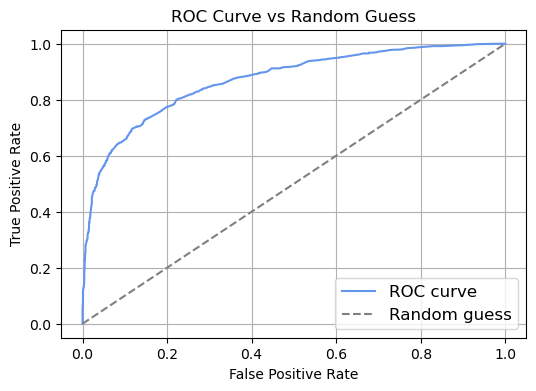

In [77]:
# Plot the ROC curve
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_pred)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color = 'cornflowerblue', label = 'ROC curve')
plt.plot([0,1],[0,1],'--', color='gray', label = 'Random guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve vs Random Guess')
plt.legend(fontsize = 12)
plt.grid(True)

## Area Under the Curve (AUC)

To further quantify the discriminatory performance illustrated by the ROC curve, the Area Under the Curve (AUC) is commonly used as a summary measure. It represents the probability that the model assigns a higher predicted default probability to a randomly selected default borrower than to a randomly selected non-default borrower.

The value of AUC ranges between 0.5 and 1.0, where a higher AUC indicates that the model has a stronger ability to correctly rank defaulted borrowers above non-defaulted borrowers.

In [78]:
from sklearn.metrics import roc_auc_score

AUC = roc_auc_score(y_test, y_pred)
print(f"The AUC of Logistic Model: {AUC:.4f}")

The AUC of Logistic Model: 0.8700


## Gini Index 

While the AUC measures the overall discriminatory power of the model, the Gini index is often used as a complementary and more intuitive metric, particularly in credit risk modeling. It transforms the AUC into a standardised scale ranging from 0 to 1 using the following formula:

$$\text{Gini} = 2 \times \text{AUC} - 1$$

This transformation makes it easier to compare model performance across different datasets or time periods and is widely adopted in the financial industry as a benchmark for evaluating credit scoring models.

In [79]:
gini = 2 * roc_auc_score(y_test, y_pred) - 1
print(f"The Gini index of Logistic model is: {gini:.4f}")

The Gini index of Logistic model is: 0.7400


**Conclusion**: 

The model achieved a Gini index of 0.7400, indicating strong discriminatory ability in ranking default borrowers above non-default borrowers.

## Lorenz Curve 

The Lorenz Curve, originally used in economics to measure inequality in the distribution of income or wealth, is applied in credit risk modelling to evaluate a model’s ability to rank defaulted borrowers effectively. A well-performing model should concentrate defaulted borrowers at the high end of predicted probabilities, indicating that these borrowers are assigned higher probabilities of default compared with non-defaulted borrowers.  

In the Lorenz Curve plot, the x-axis represents the cumulative proportion of borrowers ranked from highest to lowest predicted risk, while the y-axis represents the cumulative proportion of actual defaulted borrowers captured by the model. The diagonal dashed line represents random guessing, where defaults are uniformly distributed across all borrowers.

The orange shaded area above the diagonal line illustrates the model's additional discriminatory power relative to random guessing. The Gini coefficient is defined as the ratio of this additional area to the total triangular area under the diagonal line (0.5), providing a standardised measure of the model’s ranking performance.

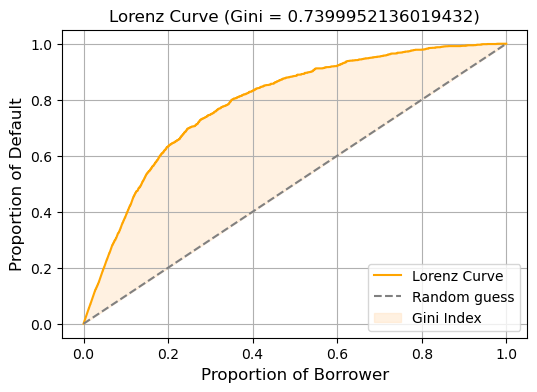

In [80]:
# Plot the Lorenz curve
test_pred = np.array(list(zip(y_test, y_pred)))
# Rank by predicted data
test_pred = test_pred[test_pred[:, 1].argsort()[::-1]]

# Y-axis: Cumulative of actual default borrower
cum_default = np.cumsum(test_pred[:, 0]) / np.sum(test_pred[:, 0])
# X-axis: The ratio of current to aggregate number of borrower 
cum_num = np.arange(1, len(y_test) + 1) / len(y_test)

plt.figure(figsize = (6, 4))
plt.plot(cum_num, cum_default, label = 'Lorenz Curve', color = 'orange')
plt.plot([0, 1], [0, 1], '--', color = 'grey', label = 'Random guess')
plt.fill_between(cum_num, cum_default, cum_num, color = 'bisque', alpha = 0.5, label = 'Gini Index')

plt.title(f'Lorenz Curve (Gini = {gini})')
plt.xlabel('Proportion of Borrower', fontsize = 12)
plt.ylabel('Proportion of Default', fontsize = 12)
plt.legend(loc = 'lower right', fontsize = 10)
plt.grid(True)
plt.show()

**Conclusion**: 

The Lorenz curve showed that the model effectively ranked defaulted borrowers toward the top of the risk distribution, where the riskiest 20% of borrowers account for more than 60% of all defaults.

## Kolmogorov-Smirnov (KS) Value 

Since the logistic regression model outputs a probability of default for each borrower, a decision threshold is required to determine which borrowers should be classified as defaulted. Several methods can be used to select the optimal threshold. One of the most widely used metrics in credit risk modeling is the Kolmogorov–Smirnov (KS) statistic, which is closely related to Youden’s J statistic.

Youden’s J is defined as the difference between the True Positive Rate (TPR) and the False Positive Rate (FPR) at each threshold:  

$$J = \mathrm{TPR} - \mathrm{FPR}$$

The KS statistic represents the maximum value of Youden’s J statistic across all possible thresholds, indicating the threshold at which the model achieves the best separation between default and non-default borrowers.

$$\quad\mathrm{KS} = \max_{\text{threshold}} (J)$$

A higher KS value indicates stronger discriminatory power of the model in distinguishing between defaulted and non-defaulted borrowers.


The commonly used interpretation guidelines for the KS statistic are summarised below:
- KS < 0.2: Weak discrimination.
- 0.2 ≤ KS < 0.4: Medium discrimination. 
- 0.4 ≤ KS < 0.6: Strong discrimination. 
- KS ≥ 0.6: Very Strong discrimination.

In [81]:
# Calculate the KS value and optimal threshold
youdens_j = tpr - fpr
best_idx = np.argmax(youdens_j)

best_threshold = thresholds[best_idx]
best_tpr = tpr[best_idx]
best_fpr = fpr[best_idx]
best_ks = youdens_j[best_idx]

print(f'The best TPR: {best_tpr:.4f}')
print(f'The best FPR: {best_fpr:.4f}')
print(f'The best KS value: {best_ks:.4f}')
print(f'The best threshold: {best_threshold:.4f}')

The best TPR: 0.7300
The best FPR: 0.1487
The best KS value: 0.5813
The best threshold: 0.2503


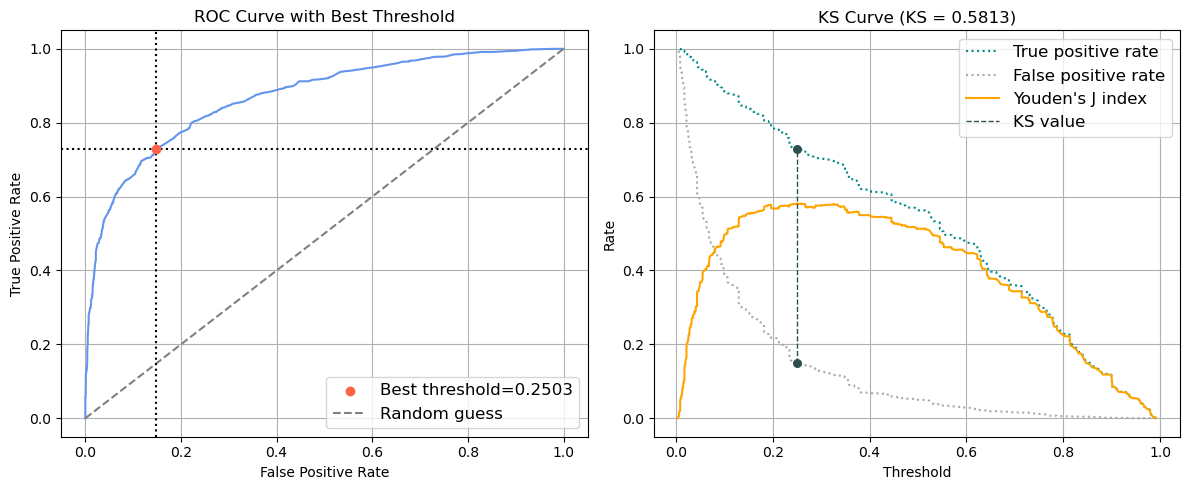

In [82]:
# Left graph: ROC curve with the best threshold
plt.figure(figsize = (12, 5))

plt.subplot(1,2,1)
plt.plot(fpr, tpr, color = 'cornflowerblue')
plt.scatter(best_fpr, best_tpr, color = 'tomato', zorder = 5,label=f'Best threshold={best_threshold:.4f}')
plt.plot([0,1],[0,1],'--', color='gray', label = 'Random guess')
plt.axvline(best_fpr, color = 'black', linestyle=':')
plt.axhline(best_tpr, color = 'black', linestyle=':')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Best Threshold')
plt.legend(fontsize = 12)
plt.grid(True)

# Right Graph: KS curve
plt.subplot(1,2,2)
plt.plot(thresholds, tpr, label = 'True positive rate', color = 'darkcyan', linestyle = ':')
plt.plot(thresholds, fpr, label = 'False positive rate', color = 'darkgray', linestyle = ':')
plt.plot(thresholds, youdens_j, label = "Youden's J index", color = 'orange')

plt.scatter([best_threshold], [best_tpr], color = 'darkslategrey', s = 30, zorder = 3)
plt.scatter([best_threshold], [best_fpr], color = 'darkslategray', s = 30, zorder = 3)
plt.vlines(x = best_threshold, ymin = best_fpr, ymax = best_tpr, 
           color = 'darkslategray', linestyle = '--', linewidth = 1, label = 'KS value')

plt.title(f'KS Curve (KS = {best_ks:.4f})')
plt.xlabel('Threshold')
plt.ylabel('Rate')
plt.legend(fontsize = 12)
plt.grid(True)

plt.tight_layout()
plt.show()

**Key Findings**:

1. The ROC curve plot showed that at the optimal threshold of 0.2503, the model correctly identified 73.00% of default borrowers (TPR = 0.7300) while incorrectly classifying 14.87%% of non-default borrowers as defaults (FPR = 0.1487).
2. The best threshold corresponded to the maximum KS value of 0.5813, representing the point at which the difference between TPR and FPR was maximized, and thus where the model achieved the strongest discrimination between default and non-default borrowers.

## Confusion Matrix

After determining the optimal classification threshold using the KS statistic, the predicted default probabilities were converted into binary classification outcomes. The confusion matrix was then constructed to evaluate the model’s classification performance. 

The confusion matrix is a fundamental tool for evaluating the classification performance of a predictive model. It compares predicted outcomes with actual outcomes, summarising the number (or proportion) of correctly and incorrectly classified borrowers.

Several key performance metrics can be derived from the confusion matrix:
1. Accuracy: The overall proportion of correctly classified borrowers.  

$$\text{Accuracy} = \frac{\text{(TP + TN)}}{\text{TP + TN + FP + FN}}$$  

2. Precision: The proportion of true default borrowers among all borrowers predicted as default.   

$$\text{Precision} = \frac{\text{TP}}{\text{TP + FP}}$$

3. Recall (or Sensitivity): The proportion of actual default borrowers that are correctly identified by the model.

$$\text{Recall} = \frac{\text{TP}}{\text{TP + FN}}$$


4. F1-score: The harmonic mean of precision and recall, providing a balanced measure between two metrics.

$$\text{F1-score} = \frac{2(\text{Precision}\ \times\ \text{Recall})}{\text{Precision + Recall}}$$

Together, these metrics provide a comprehensive evaluation of the model’s classification performance and illustrate the trade-off between correctly identifying default borrowers and minimising false alarms.

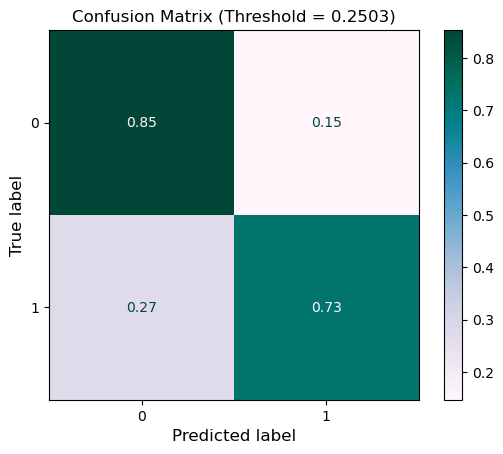

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.85      0.88      6999
           1       0.59      0.73      0.65      2000

    accuracy                           0.83      8999
   macro avg       0.75      0.79      0.77      8999
weighted avg       0.84      0.83      0.83      8999



In [83]:
# Construct the confusion matrix
from sklearn.metrics import  ConfusionMatrixDisplay ,confusion_matrix
from sklearn.metrics import classification_report

y_pred_label = (y_pred > best_threshold).astype(int)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_label, cmap = 'PuBuGn', normalize = 'true')
plt.title(f'Confusion Matrix (Threshold = {best_threshold:.4f})')
plt.xlabel('Predicted label', fontsize = 12)
plt.ylabel('True label', fontsize = 12)
plt.show()

print("=" * 60)
print("Classification Report:\n")
print(classification_report(y_test, y_pred_label))
print("=" * 60)

**Key Findings**:

1. Under the optimal threshold of 0.2503, the model correctly identified 85% of non-default and 73% of default borrowers, indicating a strong ability to distinguish between the two groups.
2. Based on the classification report, the model achieved an overall accuracy of 83%, with a precision of 0.59 and a recall of 0.73 for default borrowers. This indicated that the model successfully captured 73% of actual defaults, although approximately 41% of borrowers predicted as defaults are actually non-default borrowers.
3. The F1-score of 0.65 for the default class reflected a reasonable balance between precision and recall.

Given that failing to identify a default borrower is typically more costly than incorrectly rejecting a creditworthy borrower, the model’s relatively higher recall and moderate precision are practically acceptable in credit risk management.

## Decile Table

So far, most of the previously discussed metrics provide only an overall assessment of the model’s discriminatory power. In practice, however, risk management professionals are also interested in understanding how the model performs across different segments of borrowers. The decile table addresses this by ranking borrowers according to their predicted default probabilities, dividing them into ten groups, and calculating the observed default rate within each group to reveal performance patterns.

In general, a well-performing model should exhibit monotonically decreasing default rates from the highest-risk decile (Decile 1) to the lowest-risk decile (Decile 10), indicating that the model successfully ranks borrowers according to their actual risk levels.

In [84]:
# Construct the decile table
decile_table = pd.DataFrame(test_pred)

column_names = {
    0: 'y_true',
    1: 'y_pred'
}

decile_table.rename(columns = column_names, inplace=True)

# Segment the dataset into 10 groups
decile_table['decile'] = pd.qcut(decile_table['y_pred'], 10, labels = False, duplicates = 'drop') + 1
decile_table['decile'] = 11 - decile_table['decile']

# Calculate the number of total and default borrower in each decile
decile_table = decile_table.groupby('decile').agg(
    total = ('y_true', 'count'),
    default = ('y_true', 'sum')
).reset_index() # Set decile as new index

decile_table['bad_rate'] = decile_table['default'] / decile_table['total']
decile_table['cum_default'] = decile_table['default'].cumsum()
decile_table['cum_default_rate'] = decile_table['cum_default'] / decile_table['default'].sum()
decile_table['gain'] = decile_table['cum_default_rate']
decile_table['lift'] = decile_table['gain'] / (decile_table['decile'] * 0.1)

decile_table

,decile,total,default,bad_rate,cum_default,cum_default_rate,gain,lift
0,1,890,763.00,0.86,763.00,0.38,0.38,3.81
1,2,853,480.00,0.56,1243.00,0.62,0.62,3.11
2,3,846,231.00,0.27,1474.00,0.74,0.74,2.46
3,4,985,184.00,0.19,1658.00,0.83,0.83,2.07
4,5,918,111.00,0.12,1769.00,0.88,0.88,1.77
5,6,905,72.00,0.08,1841.00,0.92,0.92,1.53
6,7,817,64.00,0.08,1905.00,0.95,0.95,1.36
7,8,934,52.00,0.06,1957.00,0.98,0.98,1.22
8,9,806,26.00,0.03,1983.00,0.99,0.99,1.10
9,10,1045,17.00,0.02,2000.00,1.00,1.00,1.00


**Key Findings:**

1. The decile table displayed a clear monotonic decrease in default rates from 86% in Decile 1 to 2% in Decile 10, indicating strong ranking ability of the model. 
2. The top two deciles capture 62% of total defaults, highlighting the model’s effectiveness in identifying high-risk borrowers.

## Gain and Lift Charts

Building on the decile table, the gain and lift charts are derived to further visualise the model’s ability to identify high-risk borrowers. The gain chart shows the cumulative proportion of defaults captured when selecting the top percentage of borrowers ranked by their predicted probabilities of default. 

For a well-performing model, the gain curve should rise steeply toward the upper-left corner, indicating that a large proportion of default are concentrated among the highest-risk borrowers. As the proportion of borrowers increases, the curve gradually flattens, reflecting that most defaulted borrowers have already been captured. 

Although the gain chart and the Lorenz curve share similar axes, they convey different insights. The Lorenz curve emphasises the model's discriminatory power in ranking defaulted borrowers, whereas the gain chart highlights the model's practical effectiveness in capturing defaults within the top-ranked borrower segments. This makes the gain chart particularly useful for evaluating credit risk management strategies.

Complementing the gain chart, the lift chart further quantifies the model's effectiveness in identifying defaulted borrowers within each decile compared with random selection. The lift value is derived from the gain and can be calculated as follows:

$$\text{Lift}_i = \frac{\text{Gain}_i}{\text{Cumulative Proportion}_i}$$

For a well-performing model, lift values are highest in the top deciles and gradually converge toward 1, which is the level expected under random selection, as most defaulted borrowers are already captured by the model.

In summary, the gain chart illustrates the model's absolute effectiveness in capturing defaults, whereas the lift chart highlights its relative improvement over random selection.

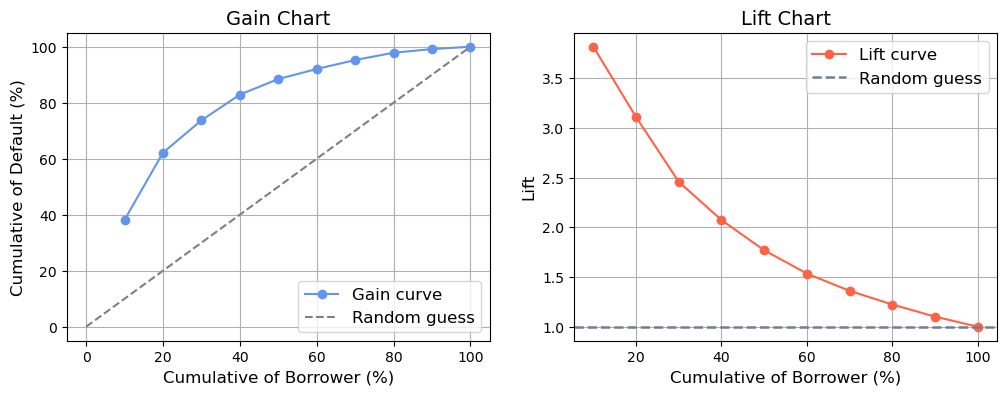

In [85]:
# Gain chart
plt.figure(figsize = (12, 4))

plt.subplot(1, 2, 1)
plt.plot(decile_table['decile'] * 10, decile_table['gain'] * 100, color = 'cornflowerblue',marker = 'o', label = 'Gain curve')
plt.plot([0, 100], [0, 100], '--', color = 'grey', label = 'Random guess')
plt.xlabel('Cumulative of Borrower (%)', fontsize = 12)
plt.ylabel('Cumulative of Default (%)', fontsize = 12)
plt.title('Gain Chart', fontsize = 14)
plt.legend(fontsize = 12, loc = 'lower right')
plt.grid(True)

# Lift chart
plt.subplot(1, 2, 2)
plt.plot(decile_table['decile'] * 10, decile_table['lift'], marker = 'o', color = 'tomato', label = 'Lift curve')
plt.axhline(1, linestyle = '--', color = 'slategrey', label = 'Random guess', linewidth = 1.8)
plt.xlabel('Cumulative of Borrower (%)', fontsize = 12)
plt.ylabel('Lift', fontsize = 12)
plt.title('Lift Chart', fontsize = 14)
plt.legend(fontsize = 12)
plt.grid(True)
plt.show()

**Key Findings**:

1. The gain chart indicated that the model captured more than 60% of all defaults within the top 20% of borrowers ranked by predicted default probability.
2. The lift chart showed that borrowers in the highest-risk decile were nearly four times more likely to default than the average borrower (random selection baseline), confirming the model's strong ability to identify high-risk borrowers.

# Calibration Analysis

The discrimination analysis revealed that the logistic default prediction model demonstrated strong ranking ability, indicating that it can effectively distinguish between defaulted and non-defaulted borrowers. However, it remained unclear whether the predicted probabilities of default were accurate in magnitude.

In this section, the calibration of the predicted probabilities of default is further evaluated to determine whether the estimated probabilities correspond to the observed default frequencies in the data.

## Calibration Curve

The calibration curve is commonly used to evaluate whether the model’s predicted probabilities of default are consistent with the observed default rates.

In the calibration plot, borrowers are divided into ten deciles based on their predicted default probabilities. Each point represents a comparison between the average predicted probability of default and the actual observed default rate within the corresponding group. The calibration curve is then compared with the diagonal reference line representing perfect calibration, where the predicted and observed default rates are identical.

Calibration analysis is particularly important because it evaluates the model’s ability to accurately estimate the true default rate, which directly affects a bank’s credit risk capital requirements and the calculation of risk-weighted assets (RWA) under the Basel framework.

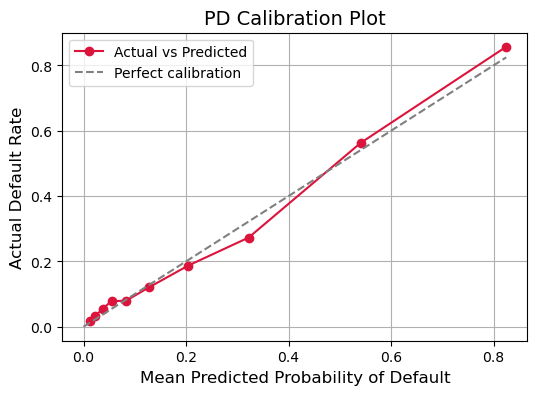

In [86]:
# Plot the calibration curve
pd_df = pd.DataFrame({'y': y_test, 'p': y_pred})
pd_df['bucket'] = pd.qcut(pd_df['p'], 10, duplicates = 'drop')

summary = pd_df.groupby('bucket').agg(
    predicted_PD = ('p', 'mean'),
    actual_ODR = ('y', 'mean'),
    count = ('y', 'count')
).reset_index()

plt.figure(figsize = (6, 4))
plt.plot(summary['predicted_PD'], summary['actual_ODR'], 'o-', label = 'Actual vs Predicted', color = 'crimson')
plt.plot([0, summary['predicted_PD'].max()], [0, summary['predicted_PD'].max()], '--', 
         label = 'Perfect calibration', color = 'grey')

plt.xlabel('Mean Predicted Probability of Default', fontsize = 12)
plt.ylabel('Actual Default Rate', fontsize = 12)
plt.title('PD Calibration Plot', fontsize = 14)
plt.legend(fontsize = 10)
plt.grid(True)
plt.show()

**Conclusion**: 

The calibration plot indicated that the model was generally well calibrated, as the predicted probabilities closely aligned with the observed default rates, with only minor deviations across certain risk segments.

## Brier Score

The Brier Score (BS) quantifies the mean squared error between the predicted probability of default and the actual default outcome. Therefore, a smaller Brier score indicates better overall calibration and higher accuracy in probability estimation.

Unlike the calibration plot, which evaluates how well the model performs across different probability deciles, the Brier score provides a single quantitative metric that summarises the model’s overall calibration quality across the entire dataset.

$$\text{BS} = \frac{1}{N}\sum_{i=1}^{N}(\hat{p}_i - y_i)^2$$

where:
- $\hat{p}_i$ denotes the probability of default predicted by model.
- $y_i$ represents the actual outcome (0: repaid, 1: default).
- $N$ is the sample size.

The general interpretation guidelines for the Brier score are as follows:
- BS = 0: Perfect calibration.
- 0 ≤ BS < 0.25: Good calibration.
- 0.25 ≤ BS < 0.50: Fair calibration.
- BS ≥ 0.5: Poor calibration.

In [87]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, y_pred)
print(f'The Brier Score of Logistic Model: {brier:.4f}')

The Brier Score of Logistic Model: 0.1039


**Conclusion**: The model demonstrated good calibration performance.

To gain deeper insight into the model’s calibration behaviour, the **Murphy Decomposition** can be applied, which decomposes the Brier score into three components: Reliability, Resolution, and Uncertainty.

$$\text{BS} = \text{Reliability} - \text{Resolution} + \text{Uncertainty}$$

**Reliability** evaluates whether the model’s predicted probabilities accurately reflect the observed default rates. A lower reliability value indicates that the predicted probabilities are closer to the actual outcomes, suggesting better model calibration.

$$\text{Reliability} = \sum_{k=1}^{K}\frac{n_k}{N}(\bar{p}_k - \bar{y}_k)^2$$

**Resolution** measures how effectively the model differentiates borrowers according to their risk levels. Higher resolution indicates that the model assigns higher default probabilities to riskier borrowers and lower probabilities to safer borrowers, consistent with discrimination metrics such as AUC and KS.

$$\text{Resolution} = \sum_{k=1}^{K}\frac{n_k}{N}(\bar{y}_k - \bar{y})^2$$

**Uncertainty** reflects the overall proportion of defaulted and repaid loans in the dataset and is independent of the model itself.

$$\text{Uncertainty} = \bar{y}\times(1-\bar{y})$$
where:
- $k$ is the $k^{th}$ decile.
- $n_k$ represents the number of observations in the $k^{th}$ decile.
- $\bar{p}_k$ is the average predicted probability of default for the $k^{th}$ decile.
- $\bar{y}_k$ is the observed default rate in the $k^{th}$ decile.
- $\bar{y}$ denotes the overall default rate of the entire dataset.

In [88]:
def murphy_decomposition(y_true, y_pred, bins = 10):
    df = pd.DataFrame({'true': y_true, 'predicted': y_pred})
    df['bucket'] = pd.qcut(df['predicted'], bins, duplicates = 'drop')
    
    grouped = df.groupby('bucket').agg(
        mean_pred = ('predicted', 'mean'),
        mean_true = ('true', 'mean'),
        n = ('true', 'count')
    )
    
    N = len(df)
    true_bar = df['true'].mean()
    
    reliability = ((grouped['n'] / N) * (grouped['mean_pred'] - grouped['mean_true'])**2).sum()
    resolution = ((grouped['n'] / N) * (grouped['mean_true'] - true_bar)**2).sum()
    uncertainty = true_bar * (1 - true_bar)
    
    result = {
    'Reliability': reliability,
    'Resolution': resolution, 
    'Uncertainty': uncertainty
    }
    
    return pd.Series(result)

decomp = murphy_decomposition(y_test, y_pred)

print(decomp.to_string(float_format="%.4f"))

Reliability   0.0005
Resolution    0.0673
Uncertainty   0.1729


## Hosmer-Lemeshow Test

Beyond graphical and numerical calibration measures, statistical hypothesis testing can provide additional evidence regarding model calibration. One commonly used approach is the Hosmer–Lemeshow (H–L) test.

The test evaluates whether the predicted probabilities generated by the model are consistent with the observed default outcomes. It involves dividing the dataset into several subgroups (typically deciles) based on the predicted probabilities. The H-L statistic is then computed by comparing the observed number of defaults with the expected number of defaults derived from the average predicted probability within each group. 

A statistically non-significant result (p-value > 0.05) indicates that the model fits the data well and that the predicted probabilities are well calibrated.

The null and alternative hypotheses of the H-L test are defined as follows:

$$H_0: E[y_i\mid\hat{p}_i] = \hat{p}_i$$
$$H_1: E[y_i\mid\hat{p}_i] \neq \hat{p}_i$$

And the H-L statistic is computed as:
is:
$$
H = \sum_{g=1}^{G} \frac{(o_g - e_g)^2}{e_g \left(1 - \frac{e_g}{n_g}\right)}
$$

where:

- $G$：Number of subgroups (usually 10).
- $n_g$：Number of samples in subgroup $g$.
- $o_g$：Number of observed default in subgroup $g$.
- $e_g$：Number of expected default in subgroup $g$. 

The H-L statistic follows a chi-square distribution $H \sim \chi^2_{df}$, where the degrees of freedom are $df = G - 2$ .




In [89]:
from scipy.stats import chi2

hl_data = pd.DataFrame({'true': y_test, 'predicted': y_pred})
hl_data['bin'] = pd.qcut(hl_data['predicted'], 10, duplicates = 'drop')

hl_table = hl_data.groupby('bin').agg(
    total = ('true', 'count'),
    observed = ('true', 'sum'),
    expected = ('predicted', 'sum')
)

hl_table['H'] = (hl_table['observed'] - hl_table['expected'])**2 / (hl_table['expected'] * (1 - hl_table['expected'] / hl_table['total']))
hl_stat = hl_table['H'].sum()
p_value = 1 - chi2.cdf(hl_stat, df = 8)

print(hl_table)
print(f'\nHosmer-Lemeshow statistics: {hl_stat:.4f}')
print(f'p-value: {p_value:.4f}')

                   total  observed  expected    H
bin                                              
(0.00269, 0.0174]   1045        17     12.83 1.37
(0.0174, 0.0275]     806        26     18.24 3.38
(0.0275, 0.0434]     934        52     35.10 8.45
(0.0434, 0.067]      817        64     44.68 8.84
(0.067, 0.0977]      905        72     75.06 0.14
(0.0977, 0.155]      918       111    117.60 0.42
(0.155, 0.234]       985       184    200.70 1.74
(0.234, 0.377]       846       231    272.58 9.36
(0.377, 0.667]       853       480    461.19 1.67
(0.667, 0.992]       890       763    734.15 6.48

Hosmer-Lemeshow statistics: 41.8456
p-value: 0.0000


**Conclusions**:

The test result indicated a statistically significant difference between the predicted and observed default rates. However, based on the calibration curve and Brier score, the model still demonstrated good calibration performance. This apparent discrepancy was likely due to the large sample size. In large datasets, even small deviations between predicted and observed default rates may accumulate and lead to statistical significance, while the overall calibration of the model remains acceptable.

# Internal Stability Analysis

After conducting discrimination and calibration analyses, the model’s ranking ability and predictive performance had been largely validated. However, it was also important to ensure whether the model performed consistently across different borrower subgroups. Therefore, a stability analysis was conducted.

Since only one period of data was available, the analysis focused on internal stability. Age and education were used as grouping variables, as the variables **person_gender** and **person_education** were excluded during the feature selection process. 

This analysis helped identify potential differences in risk patterns across borrower subgroups, thereby ensuring the model’s robustness and fairness while detecting possible segmentation bias or overfitting.

## Gender

In [90]:
# Prepare dataset for internal stability analysis
stab_df = df.loc[X_test.index, ['person_gender', 'person_education']]

stab_df['y_true'] = y_test
stab_df['y_pred'] = y_pred

In [91]:
stab_df.head()

,person_gender,person_education,y_true,y_pred
5161,male,Bachelor,0,0.23
20870,male,High School,0,0.01
33982,female,High School,0,0.10
35454,male,Associate,0,0.10
39117,male,Master,0,0.01


In [92]:
def internal_stability(df, var):
    result = []
    for subgroup in df[var].unique():
        sub = df[df[var] == subgroup]
        
        # In case y_true all equal to 0 or 1 within subgroup
        if sub['y_true'].nunique() < 2:
            continue
        
        auc = roc_auc_score(sub['y_true'], sub['y_pred'])
        fpr, tpr, _ = roc_curve(sub['y_true'], sub['y_pred'])
        ks = max(tpr - fpr)
        avg_pd = sub['y_pred'].mean()
        bad_rate = sub['y_true'].mean()
        bs = brier_score_loss(sub['y_true'], sub['y_pred'])
        
        result.append({
            'Subgroup': subgroup,
            'AUC': auc,
            'KS': ks,
            'Average PD':avg_pd,
            'Bad Rate': bad_rate,
            'BS': bs
        })
    return pd.DataFrame(result)

gender_stability = internal_stability(stab_df, 'person_gender')

print('=' * 50)
print('Internal Stability Analysis (Gender):')
print('-' * 50)
print(gender_stability)
print('=' * 50)

Internal Stability Analysis (Gender):
--------------------------------------------------
  Subgroup  AUC   KS  Average PD  Bad Rate   BS
0     male 0.87 0.59        0.22      0.23 0.10
1   female 0.87 0.58        0.22      0.22 0.10


**Conclusion**:

1. The internal stability analysis showed that the model performed consistently across gender groups, as evidenced by similar AUC values and KS statistics, indicating comparable discriminatory power.
2. The predicted probilities closely aligned with the observed default rates, and the Brier scores were identical for both groups, suggesting the model maintained stable predictive performance and did not exhibit significant gender-related bias.

## Education

In [93]:
edu_stability = internal_stability(stab_df, 'person_education')

print('=' * 50)
print('Internal Stability Analysis (Education):')
print('-' * 50)
print(edu_stability)
print('=' * 50)

Internal Stability Analysis (Education):
--------------------------------------------------
      Subgroup  AUC   KS  Average PD  Bad Rate   BS
0     Bachelor 0.87 0.61        0.22      0.22 0.10
1  High School 0.86 0.57        0.21      0.22 0.11
2    Associate 0.87 0.59        0.23      0.23 0.11
3       Master 0.87 0.58        0.21      0.22 0.10
4    Doctorate 0.86 0.61        0.22      0.23 0.11


**Conclusion**:

1. The internal stability analysis across education groups also showed consistent model performance, indicating similar discriminatory power and effective separation between default and non-default borrowers across all subgroups.
2. The predicted probabilities closely matched the observed default rates, and the Brier scores remained stable across groups, suggesting that the model maintained stable predictive performance across education segments and did not exhibit significant segmentation bias.

# Create Credit Scorecard

In credit risk modelling, logistic regression is commonly used to estimate the log-odds of default. However, log-odds are not easily interpretable for business users. Therefore, the model output is typically transformed into a credit score through a linear scaling function that maps the log-odds into a predefined score range. The transformation is defined as:

$$\text{Score} = A - B\times\log\text{(odds)}$$
where:
- odds represent the ratio of the probability of default to the probability of non-default.
- A and B are scaling parameters used to convert the model output into a scorecard scale.

## Determination of Scaling Factor $B$

The parameter $B$ determines the magnitude of score changes corresponding to one-unit change in the log-odds. It is calculated using the Points to Double the Odds (PDO) framework:

$$B = \frac{pdo}{\log(2)}$$  

Given that the $pdo$ is set to 20, the scaling factor becomes:

$$B = \frac{20}{\log(2)} = 28.8539$$ 

The $pdo$ represents the number of score points associated with a doubling of the odds of default. Under this setting, if a borrower’s odds of default double, their credit score will decrease by 20 points. Consequently, smaller $pdo$ values imply greater sensitivity of the score to changes in risk.

## Determination of Constant $A$

The constant $A$ is determined so that a borrower with baseline odds receives a predefined reference score of 600. It is calculated as:

$$A = \text{Score} + B\times\log\text{(odds)}$$

Assuming the baseline odds are 1:20, the constant $A$ can be computed as:

$$A = 600 + 28.8539\times\ln\left(\frac{1}{20}\right)$$  
$$A = 600 - 86.4376 = 513.5624$$  

Therefore, a borrower with odds of 1:20 corresponds to a score of approximately 513.6 before calibration.

##  Base Score Calibration

To ensure consistency between the theoretical score scaling and the actual model output, calibration is conducted using the logistic regression intercept $\beta$. The intercept represents the model's baseline log-odds when all predictor variables are equal to zero. The final base score (Basepoints) is calculated as:

$$\text{Basepoints} = A - B\times\beta_0$$  

Given that the intercept is:

$$\beta_0 = -1.3157$$

The basepoints are computed as:

$$\text{Basepoints} = 513.5624 - 28.8539 \times (-1.3157) = 551.5255 \approx 552$$

This result indicates that the actual base score of the scorecard is approximately 552 points, which is slightly lower than the theoretical baseline score of 600 due to the calibration adjustment using the model intercept.

Finally, the credit score for each borrower is calculated by summing the basepoints and the points contributed by each predictor variable:

$$\text{Final Score} = \text{Basepoints} + \sum_{i=1}^{k}{p}_i$$

where $p_i$ represents the number of points assigned to the $i^{th}$ variable’s bin, determined by its WOE and the corresponding logistic regression coefficient.

Based on the above transformation, the scorecard converts the logistic regression coefficients into interpretable point values, thereby quantifying the contribution of each predictor to the overall credit score. This approach allows financial institutions to assess borrowers’ creditworthiness through a transparent and interpretable scoring framework.

Given that the basepoints are set to 552, a borrower whose characteristics correspond to the baseline level across all variables would receive an initial credit score of approximately 552 points, with additional points added or deducted according to the borrower’s risk profile.

In [94]:
# Get the coefficients and intercept of the model
sm_params = final_logistic.params
sm_intercept = sm_params['const'] 
sm_coefs = sm_params.drop('const').values

# Create the list of features
sm_features = sm_params.drop('const').index.tolist()

In [95]:
# Create a LogisticRegression object to keep the coefficients and intercept
from sklearn.linear_model import LogisticRegression
sklearn_model = LogisticRegression()

# Coefficients and intercept (array)
sklearn_model.coef_ = np.array([sm_coefs]) 
sklearn_model.intercept_ = np.array([sm_intercept])

# Number of feature
sklearn_model.n_features_in_ = len(sm_coefs)

print(f"Coefficients: {sklearn_model.coef_}")
print(f"Intercept: {sklearn_model.intercept_}")
print(f"Number of the feature: {sklearn_model.n_features_in_}")

Coefficients: [[0.75752601 0.91887774 0.2395342  1.0244219  1.31506074 1.18999368]]
Intercept: [-1.31683602]
Number of the feature: 6


In [96]:
# Create the scorecard
scorecard = sc.scorecard(
    bins = all_bins,
    model = sklearn_model,
    xcolumns = sm_features,
    points0 = 600, # Reference score
    odds0 = 1/20, 
    pdo = 20 # Points to Double the Odds
)

In [97]:
# Output the scorecard
for var, table in scorecard.items():

    if var == "basepoints":
        base_score = int(table['points'].iloc[0])
        print(f"\nBase Score = {base_score}")
        continue

    print(f"\n{var}")

    for _, row in table.iterrows():
        bin_adj = str(row['bin'])

        # Format adjustment
        bin_adj = bin_adj.replace('%,%', ', ').replace('%','')
        bin_adj = bin_adj.replace('0.15000000000000002','0.15')
        
        print(f"If {var} in {bin_adj} -> score {int(row['points'])}")


Base Score = 552

person_income
If person_income in [-inf,40000.0) -> score -24
If person_income in [40000.0,60000.0) -> score -4
If person_income in [60000.0,80000.0) -> score 5
If person_income in [80000.0,inf) -> score 17

person_home_ownership
If person_home_ownership in OWN -> score 34
If person_home_ownership in MORTGAGE -> score 21
If person_home_ownership in OTHER, RENT -> score -14

loan_amnt
If loan_amnt in [-inf,14000.0) -> score 1
If loan_amnt in [14000.0,22000.0) -> score -3
If loan_amnt in [22000.0,inf) -> score -5

loan_percent_income
If loan_percent_income in [-inf,0.15) -> score 18
If loan_percent_income in [0.15,0.25) -> score 1
If loan_percent_income in [0.25,inf) -> score -59

loan_intent
If loan_intent in VENTURE -> score 20
If loan_intent in EDUCATION, PERSONAL -> score 9
If loan_intent in HOMEIMPROVEMENT, MEDICAL, DEBTCONSOLIDATION -> score -12

loan_int_rate
If loan_int_rate in [-inf,9.0) -> score 34
If loan_int_rate in [9.0,14.0) -> score 7
If loan_int_rate in

**Key Findings**:

Each feature contributed differently to the final credit score according to the points assigned to its corresponding bins. For example, under **person_home_ownership**, borrowers who owned their homes received +34 points, while those who rented received -14 points. This indicated that borrowers with stable housing conditions tended to be associated with lower default risk and therefore received higher credit scores. In contrast, renting might reflect relatively lower financial stability, which negatively affected the credit score. 

In [98]:
# Apply the scorecard to the dataset
X_test['loan_status'] = y_test
model_features = ['loan_int_rate', 'person_income', 'person_home_ownership', 'loan_percent_income', 'loan_intent', 'loan_amnt', 'loan_status']
sc_df = X_test[model_features]
sc_df.head()

sc_df = sc_df.copy()
score_data = sc.scorecard_ply(sc_df, scorecard)
sc_df.loc[:, 'new_credit_score'] = score_data
sc_df

,loan_int_rate,person_income,person_home_ownership,loan_percent_income,loan_intent,loan_amnt,loan_status,new_credit_score
5161,12.98,51290.00,RENT,0.09,DEBTCONSOLIDATION,4800.00,0,548.00
20870,11.01,144889.00,MORTGAGE,0.02,VENTURE,3600.00,0,636.00
33982,13.98,72935.00,RENT,0.07,PERSONAL,5000.00,0,578.00
35454,6.99,46679.00,RENT,0.18,EDUCATION,8500.00,0,579.00
39117,7.29,79122.00,OWN,0.11,PERSONAL,9000.00,0,653.00
...,...,...,...,...,...,...,...,...
8439,12.69,111490.00,RENT,0.22,HOMEIMPROVEMENT,25000.00,0,546.00
44301,10.65,29880.00,RENT,0.08,MEDICAL,2500.00,0,528.00
6766,14.65,84894.00,RENT,0.12,VENTURE,10125.00,0,552.00
10281,9.99,61779.00,RENT,0.15,EDUCATION,9400.00,0,578.00


In [99]:
sc_df['new_credit_score'].describe()

count   8999.00
mean     569.72
std       53.10
min      375.00
25%      536.00
50%      578.00
75%      609.50
max      676.00
Name: new_credit_score, dtype: float64

## Scaling the Credit Score

The credit scores generated by the scorecard model were rescaled to a FICO-like range (300–850) using min–max normalisation, where FICO refers to the scoring system developed by Fair Isaac Corporation, which is widely used in credit risk assessment. This transformation improves interpretability and allows the resulting scores to be compared with industry-standard credit scoring systems while preserving the relative ranking of borrowers.

In [100]:
# Scale of the new credit score
min_score = sc_df['new_credit_score'].min()
max_score = sc_df['new_credit_score'].max()

# Scale of the FICO credit score
min_fico = 300
max_fico = 850

# Transform to the FICO system (300 - 850)
sc_df['fico_scaled_score'] = min_fico + (sc_df['new_credit_score'] - min_score) * \
    (max_fico - min_fico) / (max_score - min_score)

print(sc_df['fico_scaled_score'].describe())

count   8999.00
mean     655.80
std       97.03
min      300.00
25%      594.19
50%      670.93
75%      728.49
max      850.00
Name: fico_scaled_score, dtype: float64


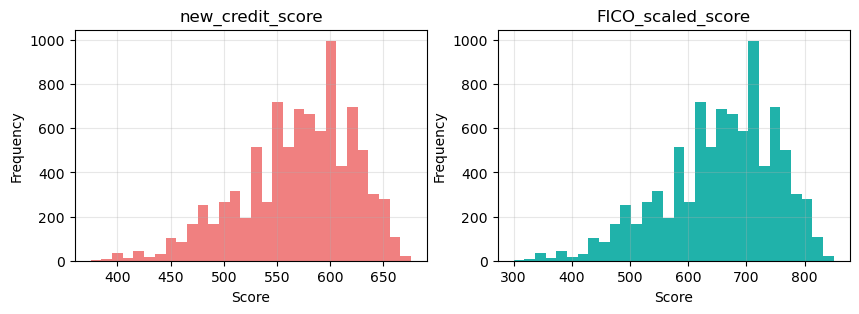

In [101]:
fig, axes = plt.subplots(1, 2, figsize = (10, 3))

# Histogram of new_credit_score
axes[0].hist(sc_df['new_credit_score'], bins = 30, color = 'lightcoral')
axes[0].set_title("new_credit_score", fontsize = 12)
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Frequency", fontsize = 10)
axes[0].grid(alpha = 0.3)

# Histogram of fico_scaled_score
axes[1].hist(sc_df['fico_scaled_score'], bins = 30, color = 'lightseagreen')
axes[1].set_title("FICO_scaled_score", fontsize = 12)
axes[1].set_xlabel("Score")
axes[1].set_ylabel("Frequency", fontsize = 10)
axes[1].grid(alpha = 0.3)

plt.show()

**Conclusion:**

The histograms indicated that both the original credit scores and the scaled FICO-like scores exhibited similar distribution patterns. The scaling transformation enhanced interpretability while maintaining the model’s ability to effectively differentiate credit risk among borrowers.

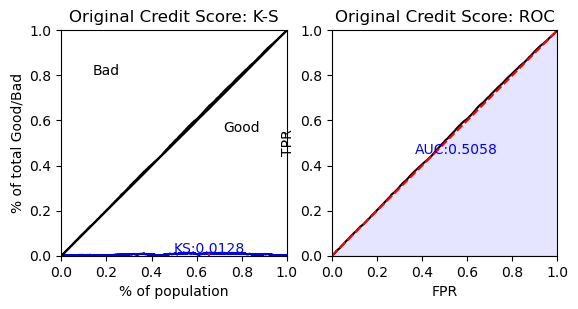

KS Statistic: 0.0128
AUC: 0.5058
Gini: 0.0115



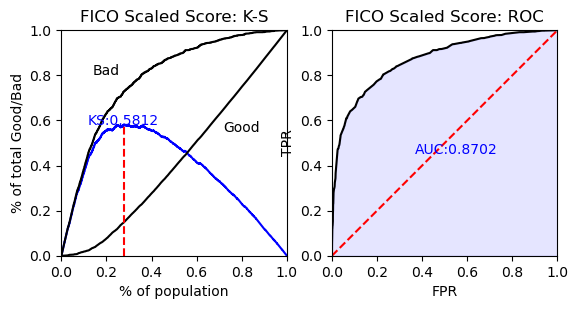

KS Statistic: 0.5812
AUC: 0.8702
Gini: 0.7404


In [102]:
# Comparison of original credit score and FICO scaled score performance

import warnings
warnings.filterwarnings("ignore")

perf = sc.perf_eva(df['loan_status'], df['credit_score'], title = 'Original Credit Score')

print(f"KS Statistic: {perf['KS']:.4f}")
print(f"AUC: {perf['AUC']:.4f}")
print(f"Gini: {perf['Gini']:.4f}")
print("\n" + '=' * 70 )

perf_fico = sc.perf_eva(y_test, sc_df['fico_scaled_score'], title = 'FICO Scaled Score')

print(f"KS Statistic: {perf_fico['KS']:.4f}")
print(f"AUC: {perf_fico['AUC']:.4f}")
print(f"Gini: {perf_fico['Gini']:.4f}")

**Conclusion**:

The original credit score in the dataset showed almost no discriminatory power, with a KS statistic of 0.0128 and an AUC close to 0.5, indicating performance similar to random guessing. In contrast, the newly scaled FICO credit score demonstrated substantially stronger discriminatory power, achieving a KS statistic of 0.5812 and an AUC of 0.8702. The Gini index also increased significantly from 0.0115 to 0.7404. These results suggested that the FICO scaled score significantly improved the model's ability to distinguish between default and non-default borrowers.

# Conclusion

In this notebook, a logistic regression-based Probaility of Default (PD) model was developed using WOE-transformed predictors. Monotonic binning was implemented via the Pool Adjacent Violators Algorithms (PAVA) to ensure a stable and interpretable relationship between predictors and default risk. Feature selection was carried out using univariate logistic regression, chi-squared tests, and LASSO regularisation. The model was subsequently validated through discrimination, calibration, and internal stability analyses.

The final model included several statistically significant predictors, namely loan_intent, loan_int_rate, loan_percent_income, person_home_ownership, person_income, and loan_amnt, ranked in descending order of their odds ratios. These variables aligned with economic intuition and common credit risk modelling practice, capturing borrowers’ repayment capacity, financial leverage, and loan characteristics that are closely associated with default risk.

The model demonstrated strong discriminatory power, as indicated by high AUC and KS statistics. Calibration assessment using the calibration curve and Brier score showed good alignment between predicted probabilities and observed default rates. Furthermore, internal stability analysis suggested consistent and fair performance across gender and education groups, supporting the model’s reliability as a tool for credit risk assessment.

Future work could extend this analysis by incorporating Population Stability Index (PSI), Characteristic Stability Index (CSI), and AUC drift to further evaluate model stability once additional time-period data becomes available.